<a href="https://www.kaggle.com/code/omborse771924/smart-city-traffic-analysis-95-accuracy?scriptVersionId=345659018" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mobeenfatimah/cityflow-smart-urban-mobility-and-traffic-iot/smart_city_traffic_mobility.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/cityflow-smart-urban-mobility-and-traffic-iot/smart_city_traffic_mobility.csv')

In [3]:
df.head()

,record_id,city_zone,road_id,intersection_id,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,...,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate,congestion_level
0,REC_0000001,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,162,...,1,Optimal,60,18,0,162.0,16.8,39.14,8.53,Low
1,REC_0000002,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,150,...,1,Optimal,60,18,0,150.0,18.4,36.09,7.83,Low
2,REC_0000003,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,186,...,1,Optimal,60,18,0,186.0,20.7,44.01,9.39,Low
3,REC_0000004,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,162,...,1,Optimal,60,18,0,162.0,17.8,38.47,8.24,Low
4,REC_0000005,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,168,...,1,Optimal,60,18,0,168.0,17.3,40.28,8.71,Low


In [4]:
df.tail()

,record_id,city_zone,road_id,intersection_id,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,...,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate,congestion_level
203995,REC_0203996,Residential West,RD_281,INT_100,40.665597,-74.039096,Local Street,2,40,224,...,3,Optimal,60,19,0,224.0,22.5,53.10,11.35,Low
203996,REC_0203997,Residential West,RD_281,INT_100,40.665597,-74.039096,Local Street,2,40,125,...,3,Optimal,60,18,0,125.0,16.6,29.62,6.33,Low
203997,REC_0203998,Residential West,RD_281,INT_100,40.665597,-74.039096,Local Street,2,40,111,...,3,Optimal,60,18,0,111.0,23.0,28.54,6.59,Low
203998,REC_0203999,Residential West,RD_281,INT_100,40.665597,-74.039096,Local Street,2,40,100,...,3,Optimal,60,18,0,100.0,12.2,25.74,5.95,Low
203999,REC_0204000,Residential West,RD_281,INT_100,40.665597,-74.039096,Local Street,2,40,114,...,3,Optimal,60,18,0,114.0,24.2,27.24,5.87,Low


In [5]:
df.info

<bound method DataFrame.info of           record_id           city_zone road_id intersection_id   latitude  \
0       REC_0000001  Financial District  RD_206         INT_001  40.757551   
1       REC_0000002  Financial District  RD_206         INT_001  40.757551   
2       REC_0000003  Financial District  RD_206         INT_001  40.757551   
3       REC_0000004  Financial District  RD_206         INT_001  40.757551   
4       REC_0000005  Financial District  RD_206         INT_001  40.757551   
...             ...                 ...     ...             ...        ...   
203995  REC_0203996    Residential West  RD_281         INT_100  40.665597   
203996  REC_0203997    Residential West  RD_281         INT_100  40.665597   
203997  REC_0203998    Residential West  RD_281         INT_100  40.665597   
203998  REC_0203999    Residential West  RD_281         INT_100  40.665597   
203999  REC_0204000    Residential West  RD_281         INT_100  40.665597   

        longitude     road_type

In [6]:
df.describe

<bound method NDFrame.describe of           record_id           city_zone road_id intersection_id   latitude  \
0       REC_0000001  Financial District  RD_206         INT_001  40.757551   
1       REC_0000002  Financial District  RD_206         INT_001  40.757551   
2       REC_0000003  Financial District  RD_206         INT_001  40.757551   
3       REC_0000004  Financial District  RD_206         INT_001  40.757551   
4       REC_0000005  Financial District  RD_206         INT_001  40.757551   
...             ...                 ...     ...             ...        ...   
203995  REC_0203996    Residential West  RD_281         INT_100  40.665597   
203996  REC_0203997    Residential West  RD_281         INT_100  40.665597   
203997  REC_0203998    Residential West  RD_281         INT_100  40.665597   
203998  REC_0203999    Residential West  RD_281         INT_100  40.665597   
203999  REC_0204000    Residential West  RD_281         INT_100  40.665597   

        longitude     road_ty

In [7]:
df.isnull()

,record_id,city_zone,road_id,intersection_id,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,...,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate,congestion_level
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
203996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
203997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
203998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

record_id                     0
city_zone                     0
road_id                       0
intersection_id               0
latitude                      0
longitude                     0
road_type                     0
lanes                         0
speed_limit                   0
vehicle_count                 0
average_speed                 0
heavy_vehicle_count           0
motorcycle_count              0
public_transport_count        0
traffic_density               0
queue_length                  0
average_wait_time             0
timestamp                     0
hour                          0
day_of_week                   0
is_weekend                    0
is_holiday                    0
rush_hour                     0
peak_period                   0
temperature                   0
rainfall_mm                   0
visibility_km                 0
air_quality_index             0
weather_condition             0
nearby_school                 0
nearby_hospital               0
nearby_m

In [9]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
203995    False
203996    False
203997    False
203998    False
203999    False
Length: 204000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['record_id', 'city_zone', 'road_id', 'intersection_id', 'latitude',
       'longitude', 'road_type', 'lanes', 'speed_limit', 'vehicle_count',
       'average_speed', 'heavy_vehicle_count', 'motorcycle_count',
       'public_transport_count', 'traffic_density', 'queue_length',
       'average_wait_time', 'timestamp', 'hour', 'day_of_week', 'is_weekend',
       'is_holiday', 'rush_hour', 'peak_period', 'temperature', 'rainfall_mm',
       'visibility_km', 'air_quality_index', 'weather_condition',
       'nearby_school', 'nearby_hospital', 'nearby_market',
       'construction_activity', 'road_condition', 'parking_occupancy',
       'public_event', 'accident_reported', 'traffic_camera_count',
       'iot_sensor_health', 'signal_cycle_seconds', 'green_light_duration',
       'emergency_vehicle_detected', 'traffic_flow_rate', 'congestion_score',
       'emission_estimate', 'fuel_waste_estimate', 'congestion_level'],
      dtype='object')

## EDA

TRAFFIC DATASET EDA
Dataset Shape: (204000, 47)

Columns:
['record_id', 'city_zone', 'road_id', 'intersection_id', 'latitude', 'longitude', 'road_type', 'lanes', 'speed_limit', 'vehicle_count', 'average_speed', 'heavy_vehicle_count', 'motorcycle_count', 'public_transport_count', 'traffic_density', 'queue_length', 'average_wait_time', 'timestamp', 'hour', 'day_of_week', 'is_weekend', 'is_holiday', 'rush_hour', 'peak_period', 'temperature', 'rainfall_mm', 'visibility_km', 'air_quality_index', 'weather_condition', 'nearby_school', 'nearby_hospital', 'nearby_market', 'construction_activity', 'road_condition', 'parking_occupancy', 'public_event', 'accident_reported', 'traffic_camera_count', 'iot_sensor_health', 'signal_cycle_seconds', 'green_light_duration', 'emergency_vehicle_detected', 'traffic_flow_rate', 'congestion_score', 'emission_estimate', 'fuel_waste_estimate', 'congestion_level']

NULL VALUES BEFORE CLEANING
record_id                          0
city_zone                          

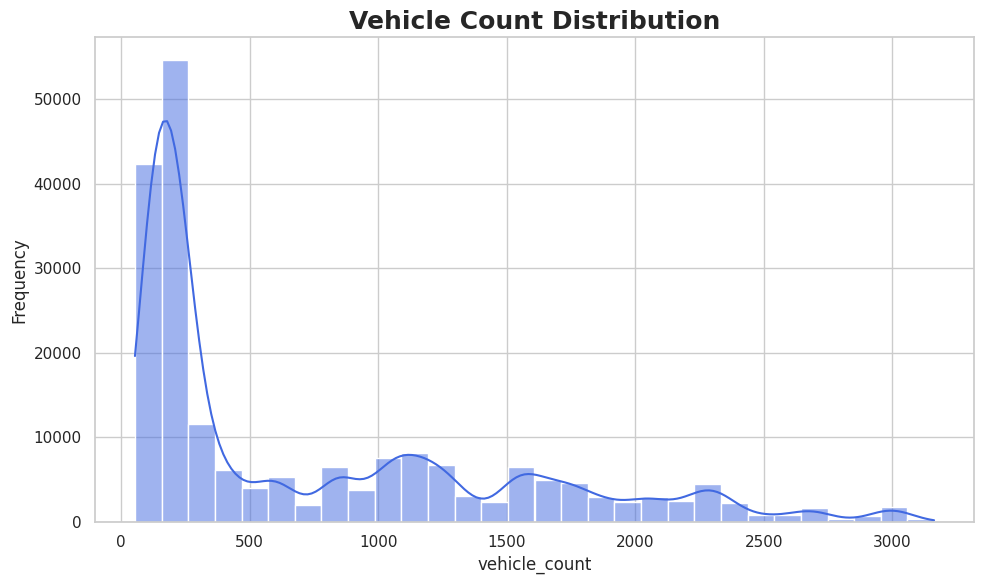

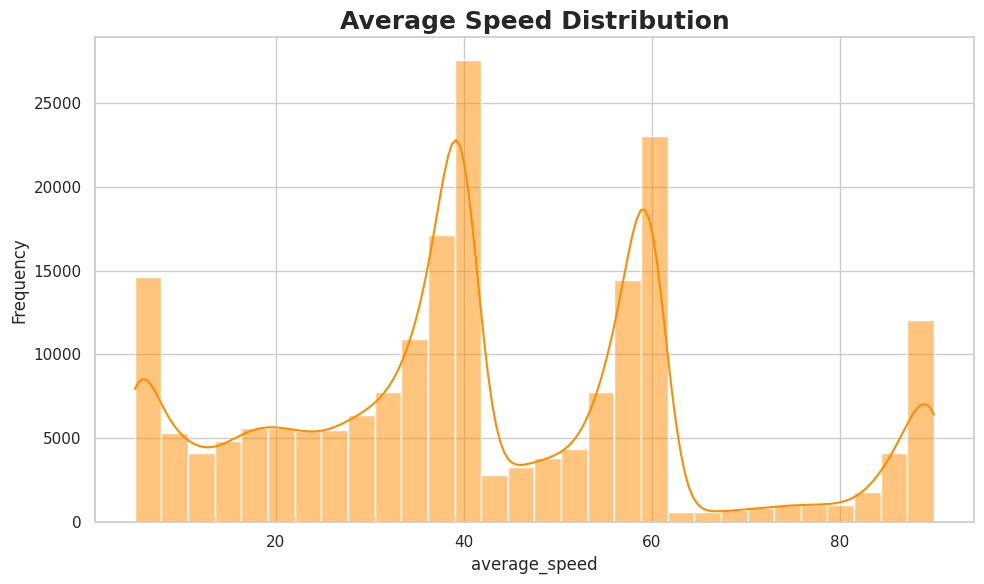

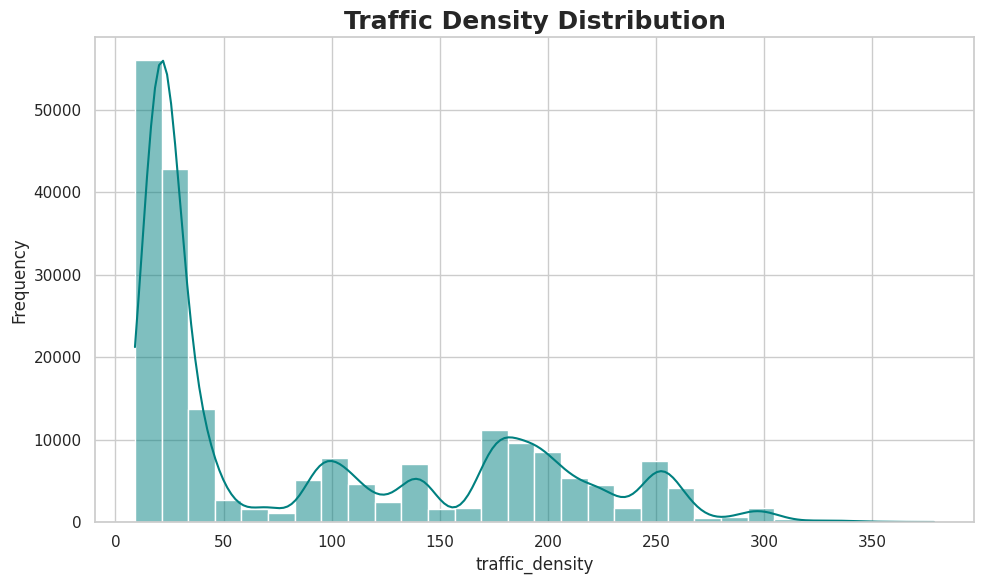

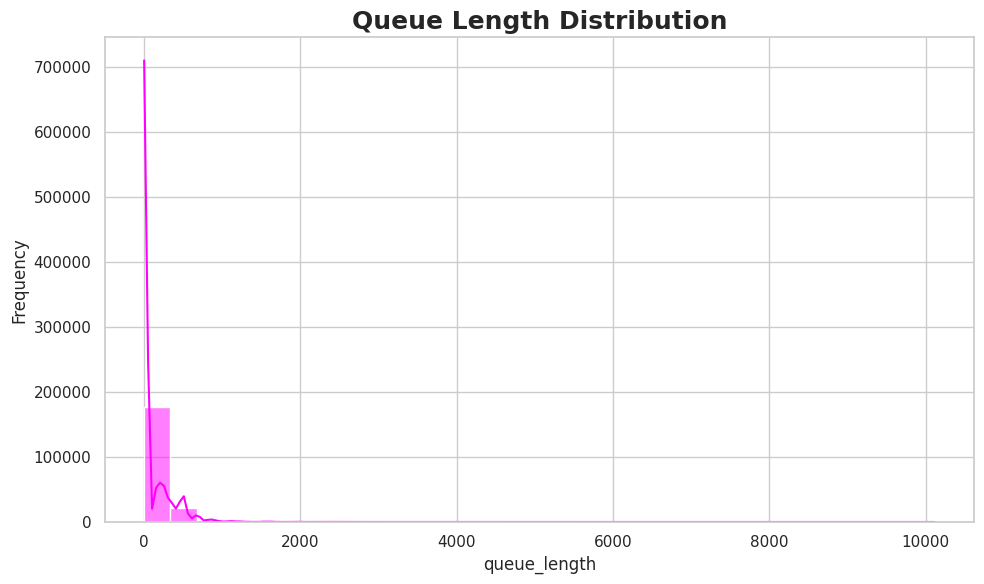

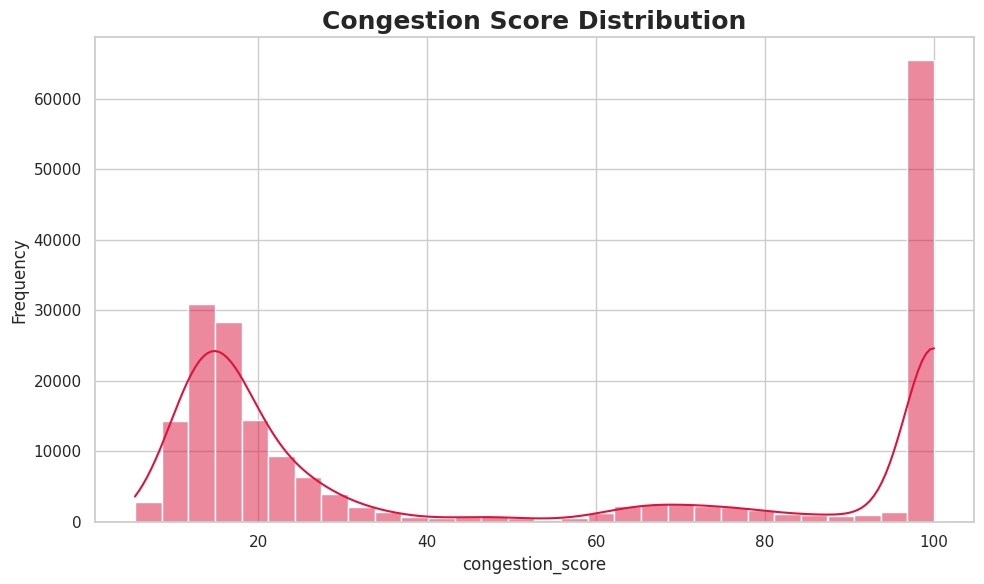

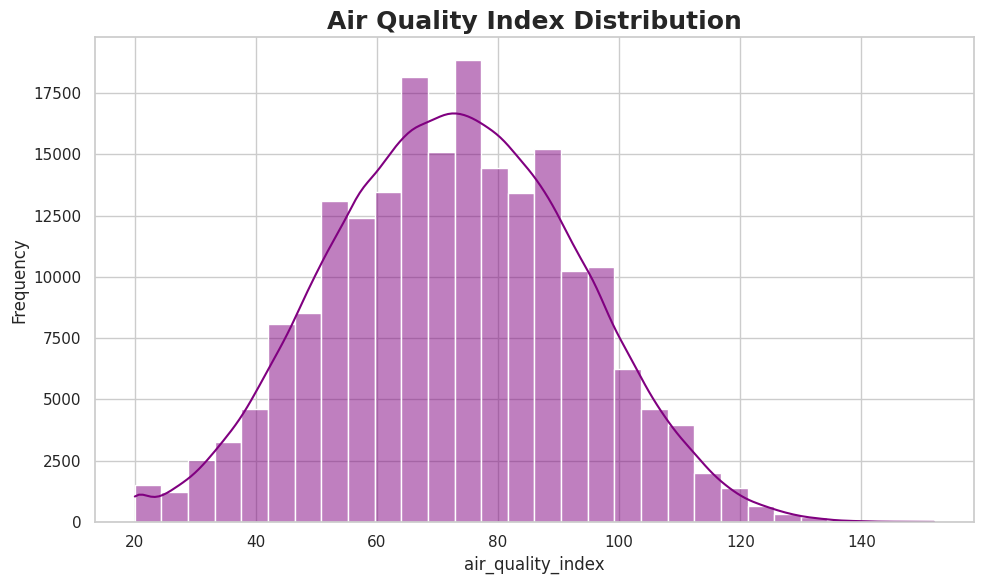

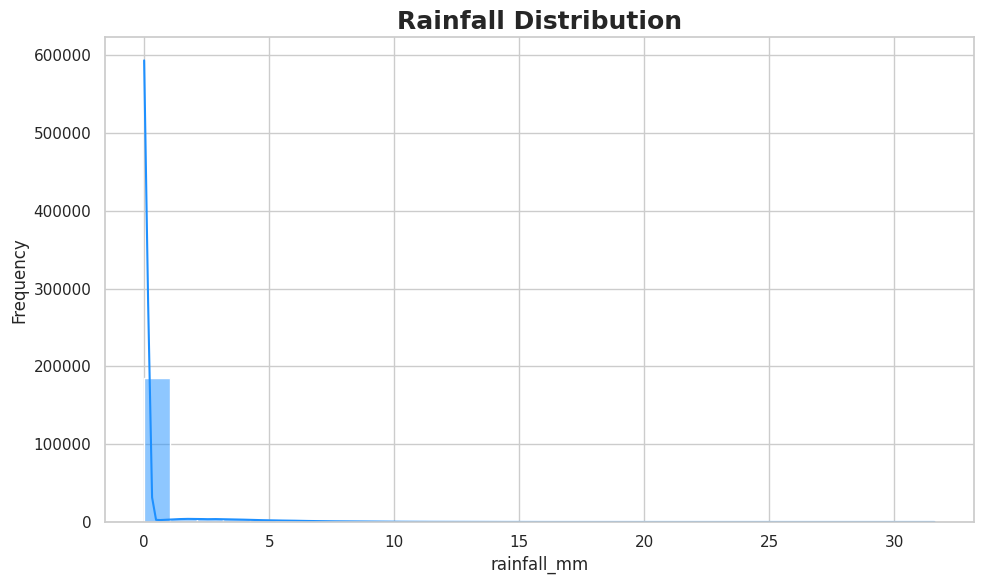

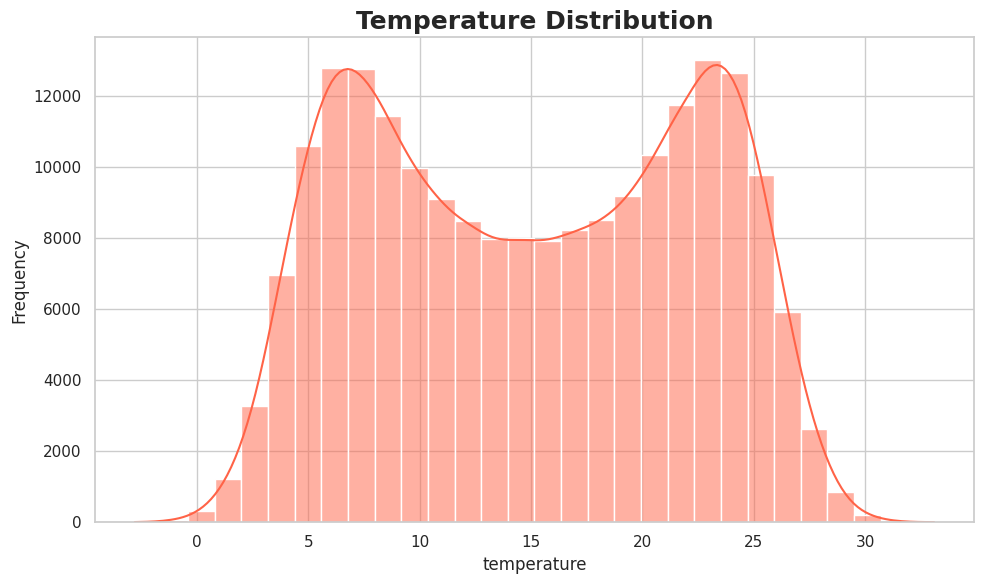

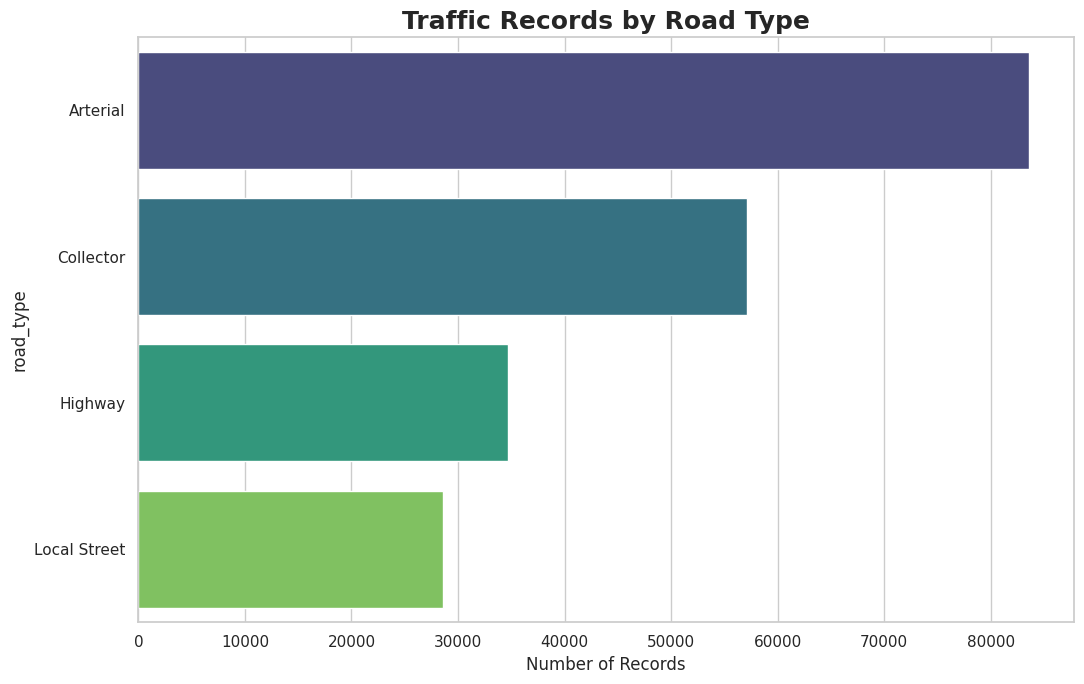

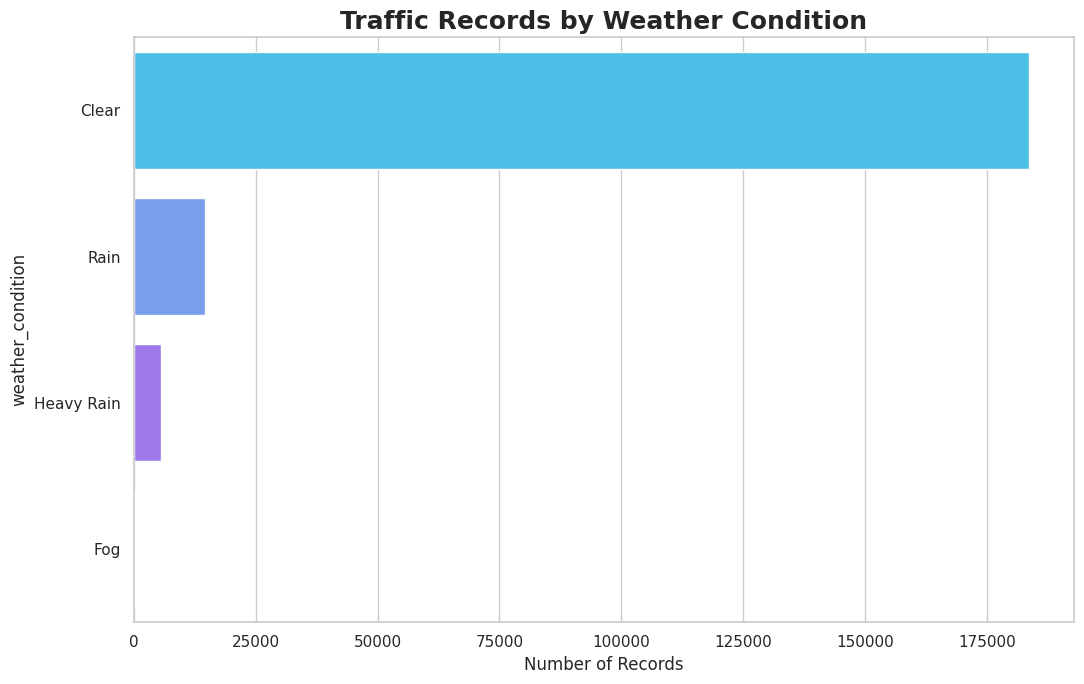

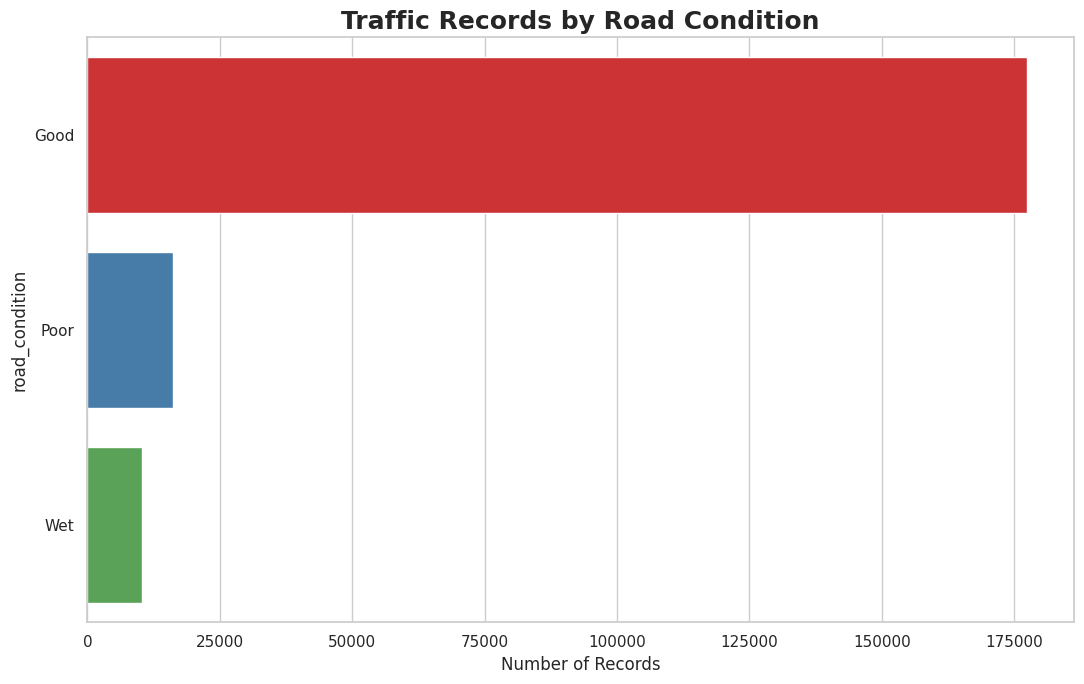

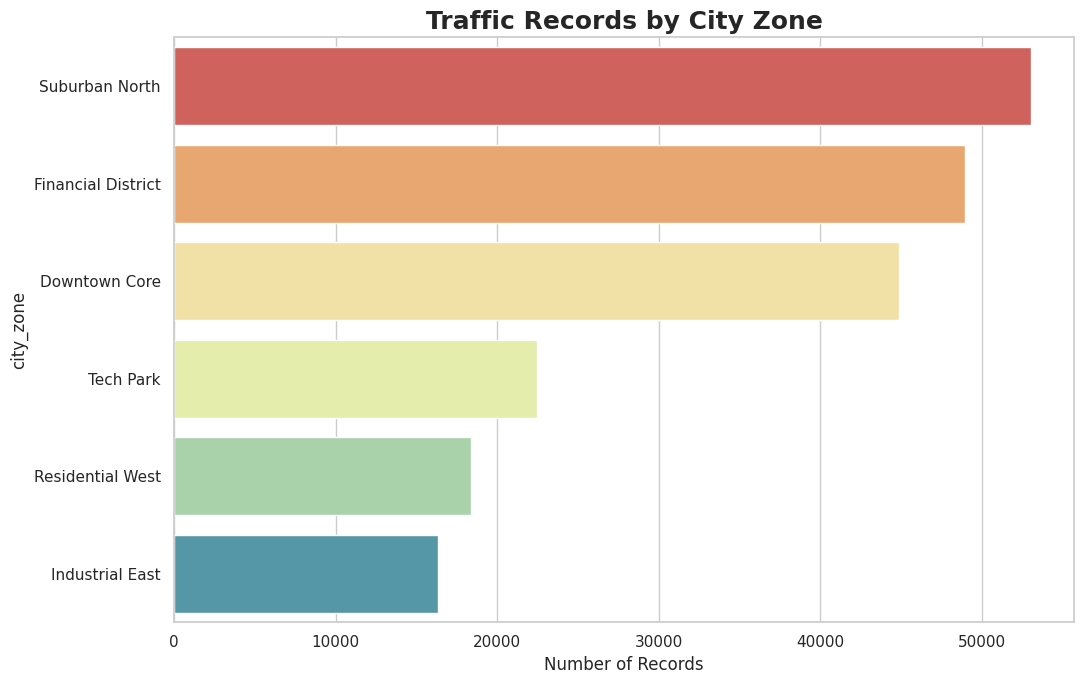

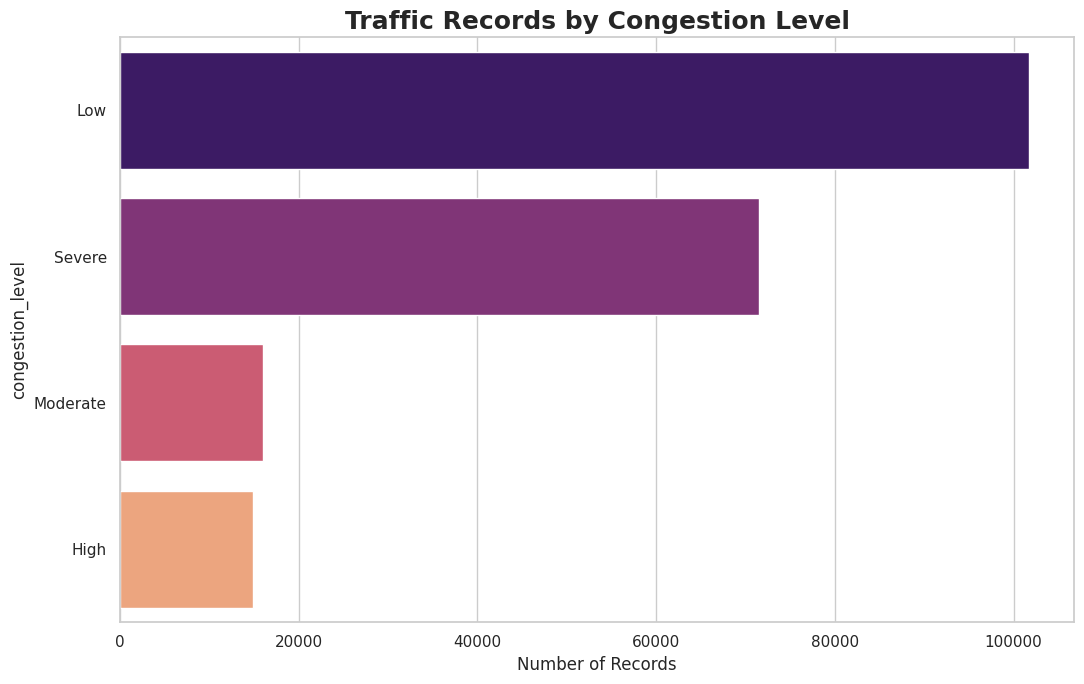


traffic_level column not available - skipped this visualization.


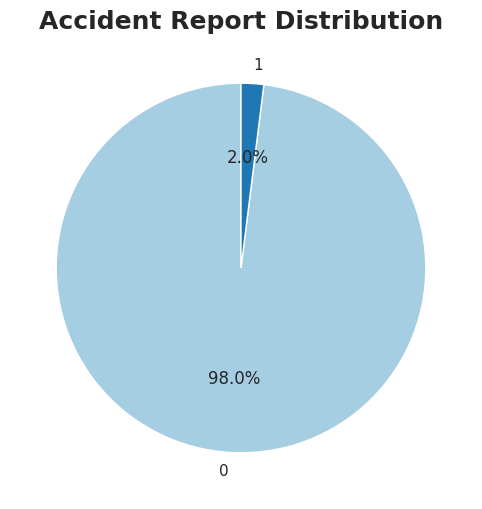

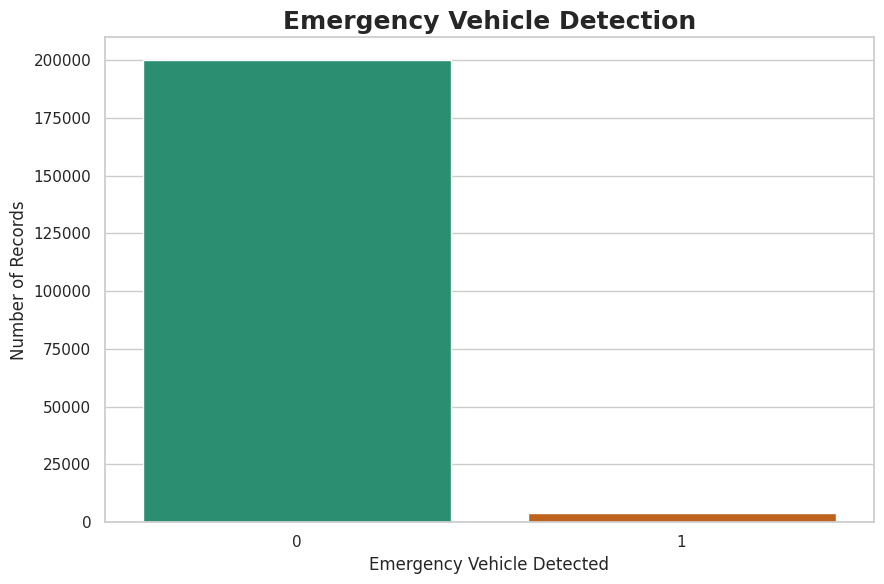

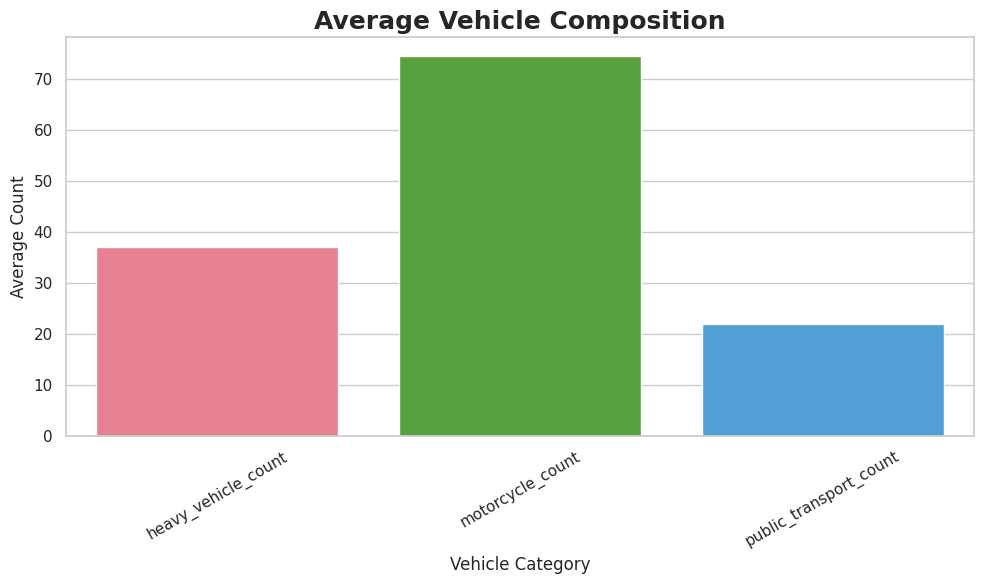

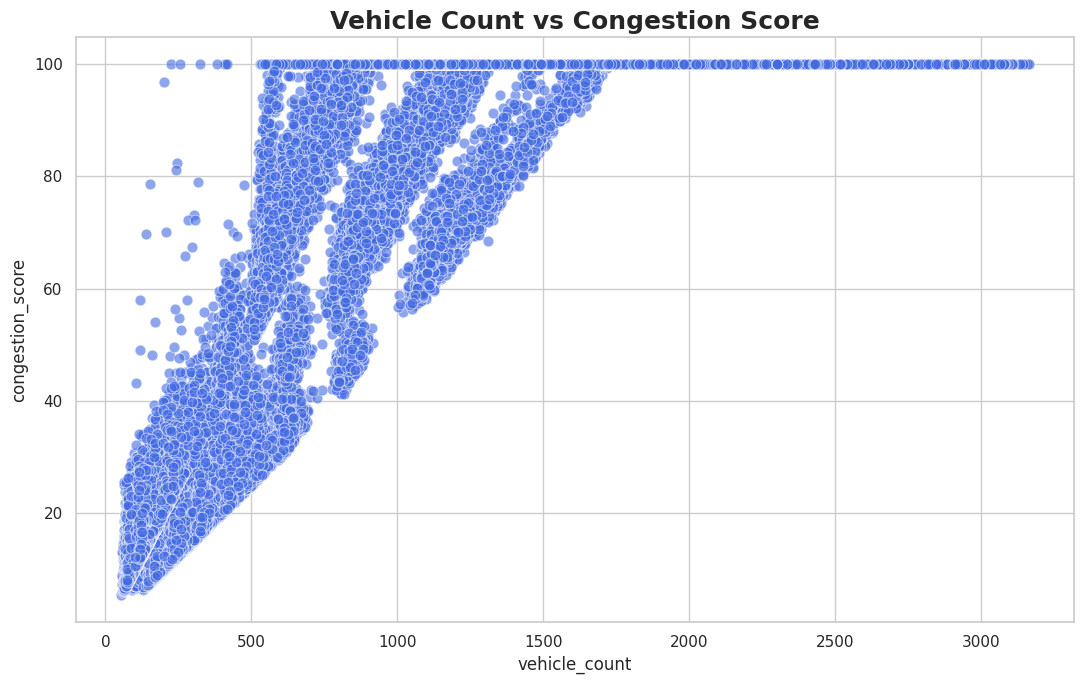

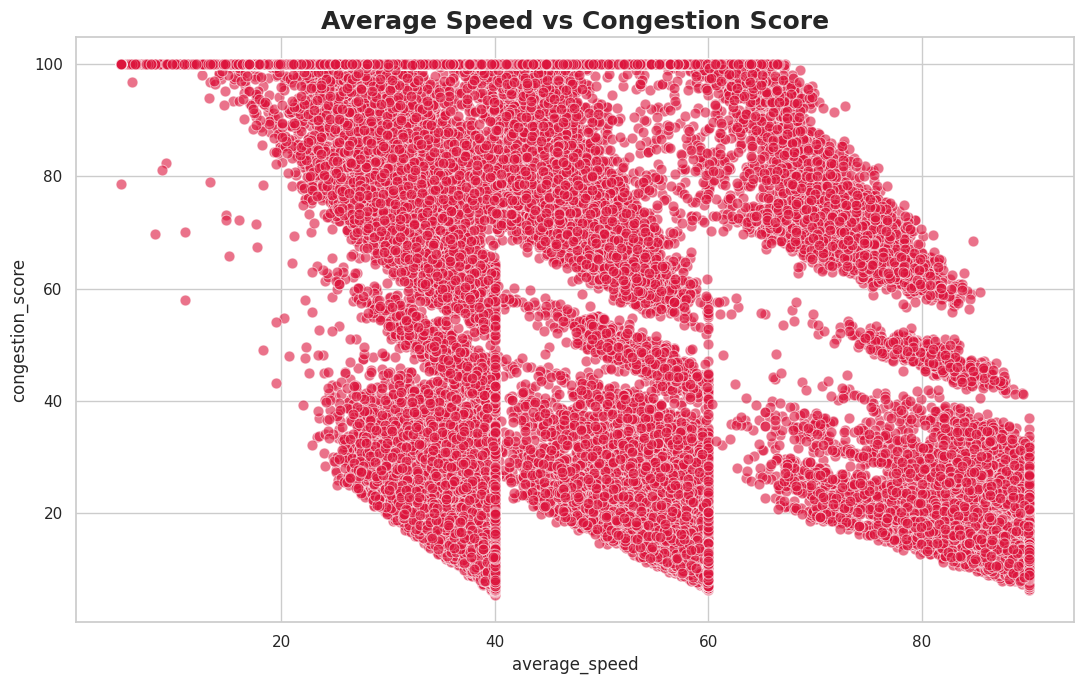

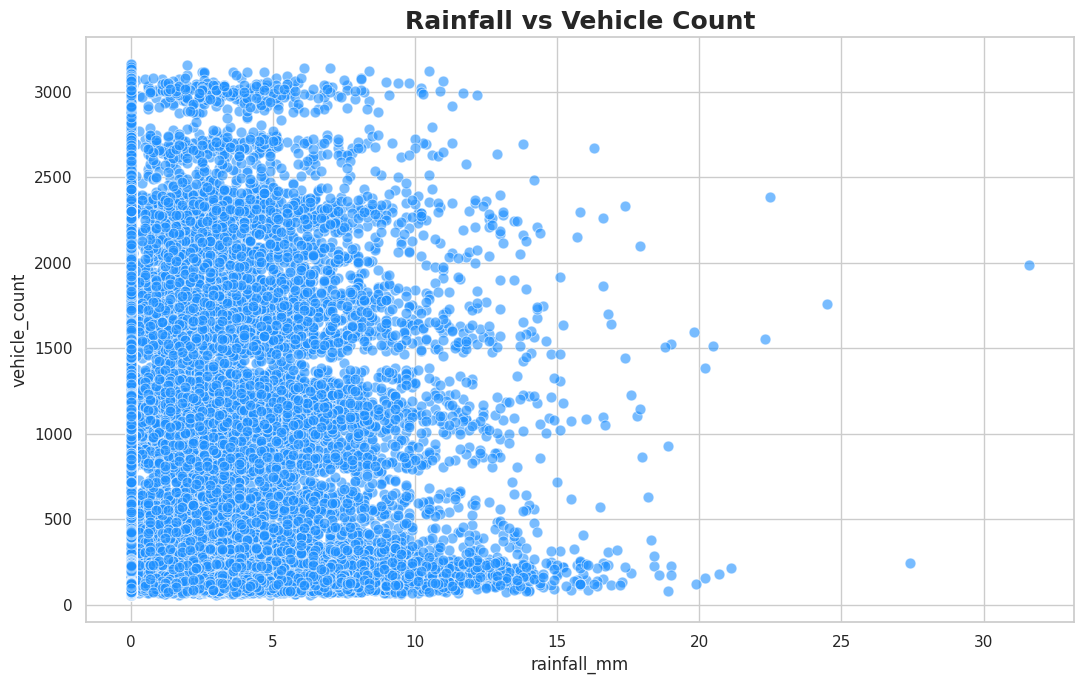

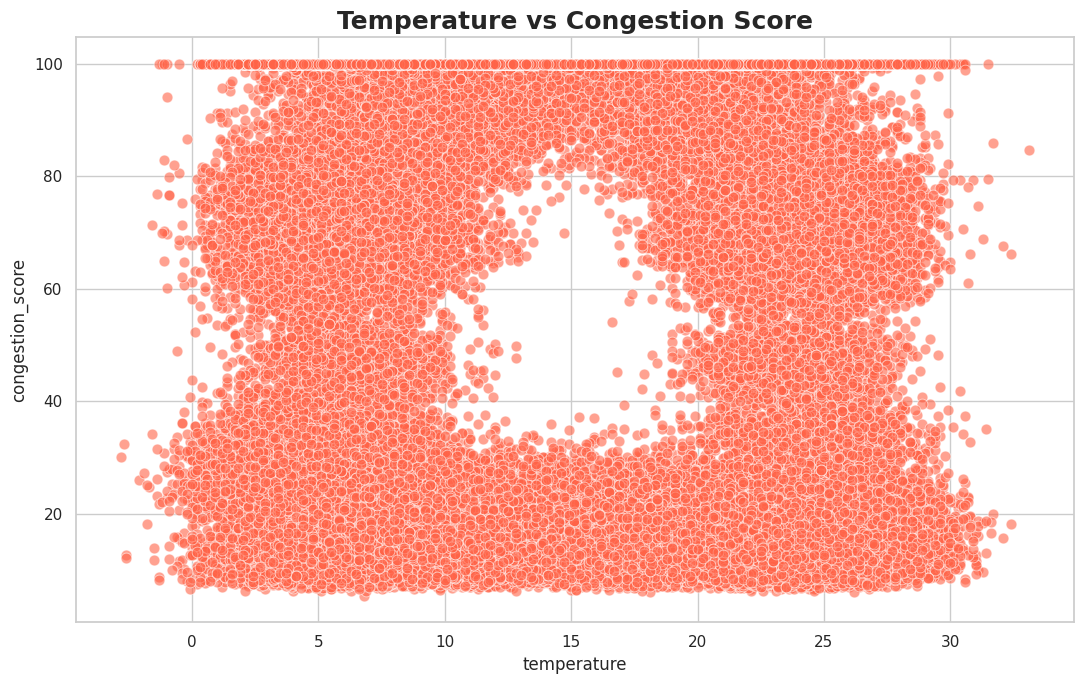

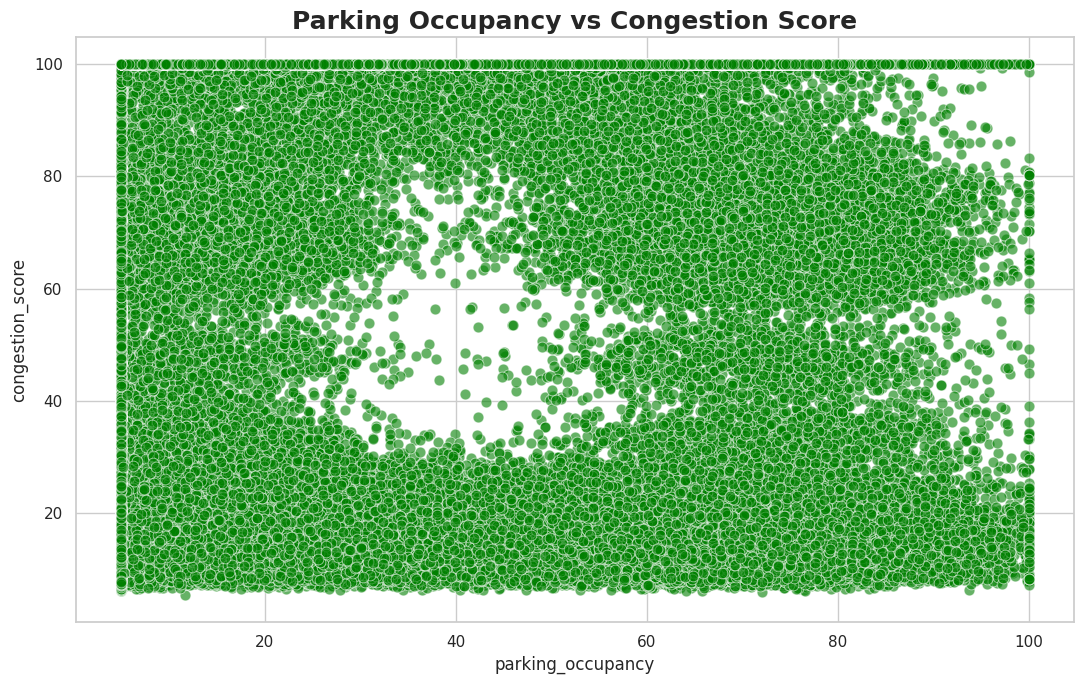

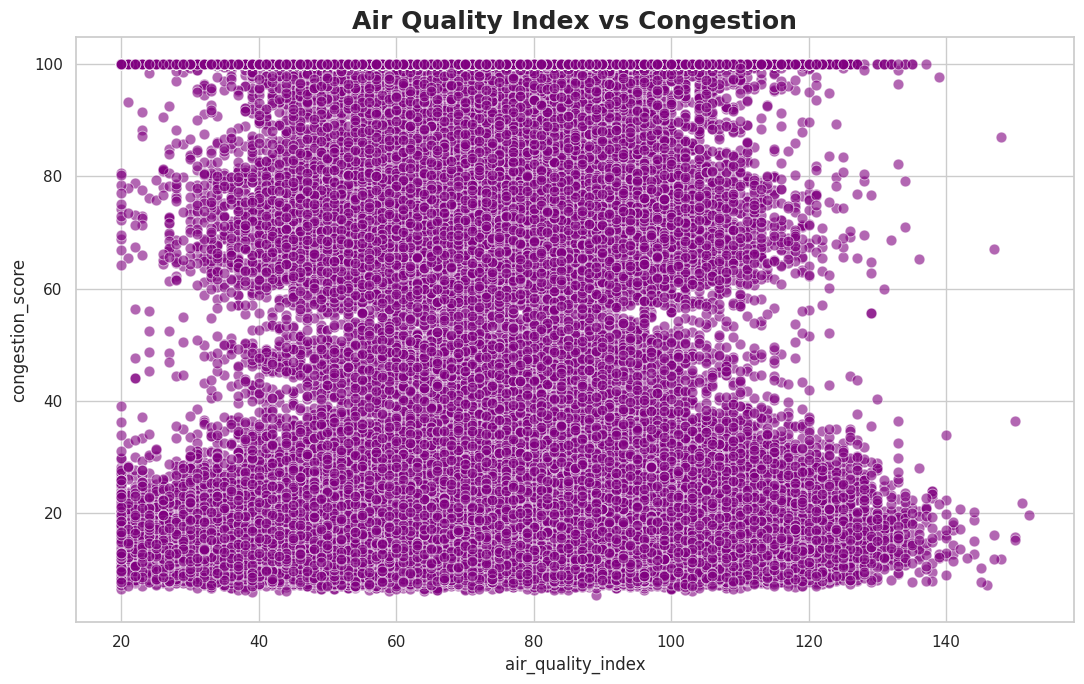

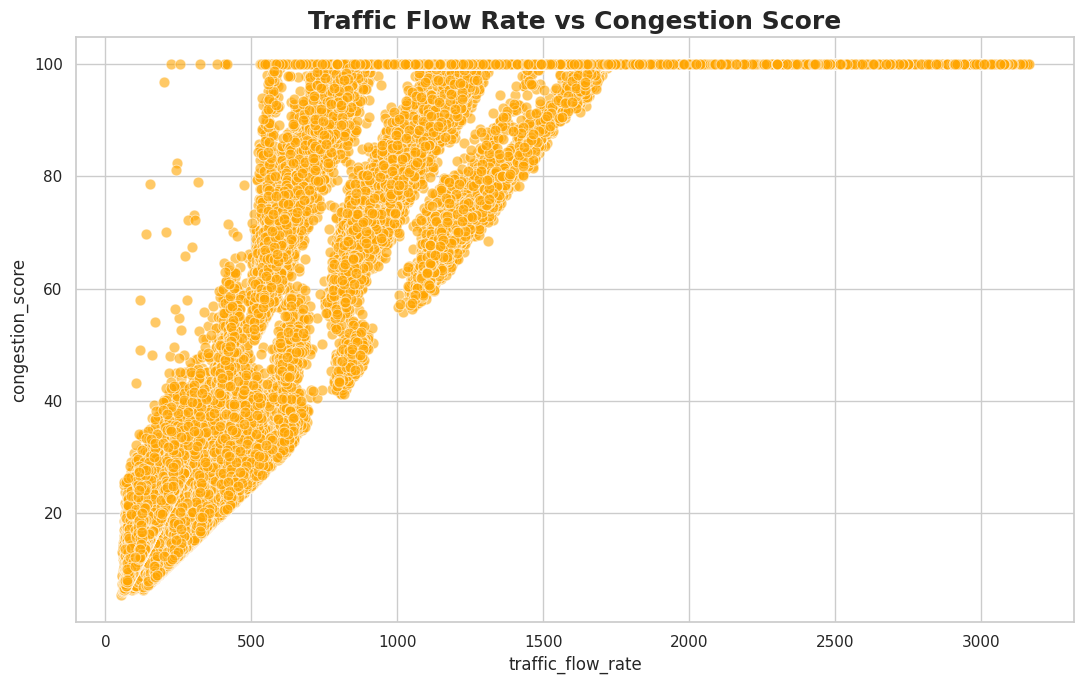

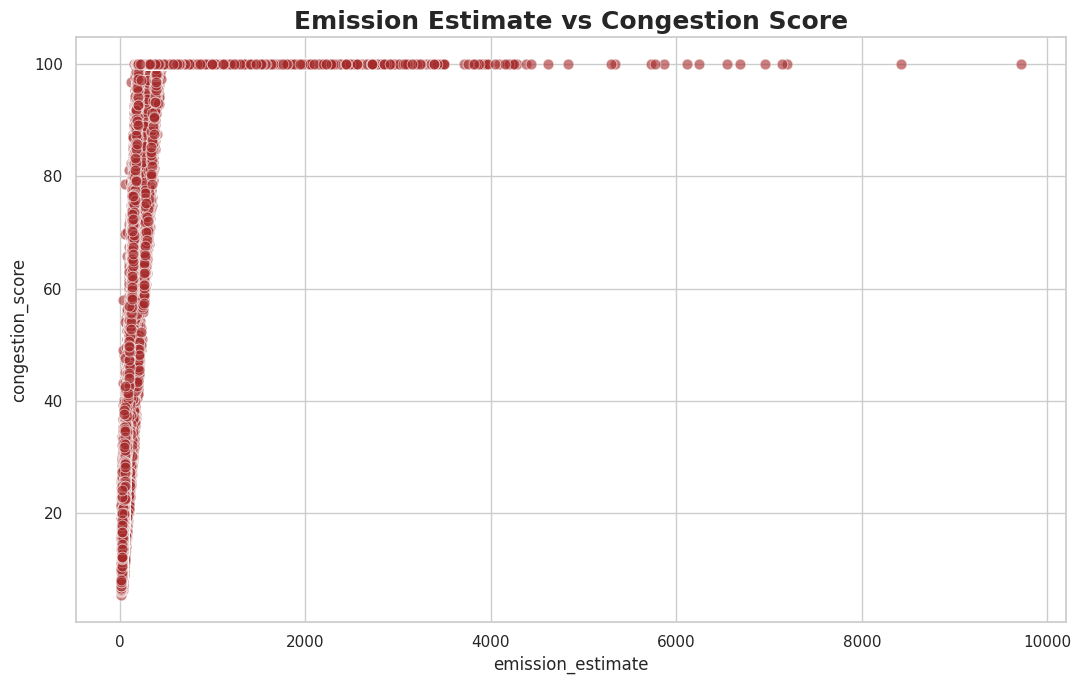

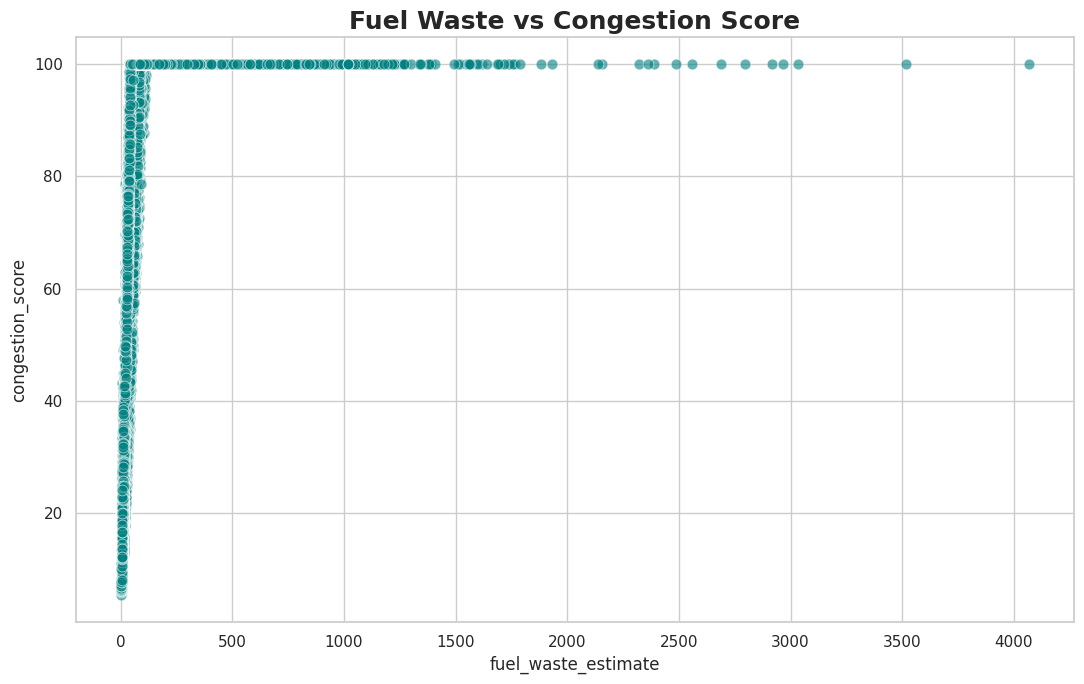

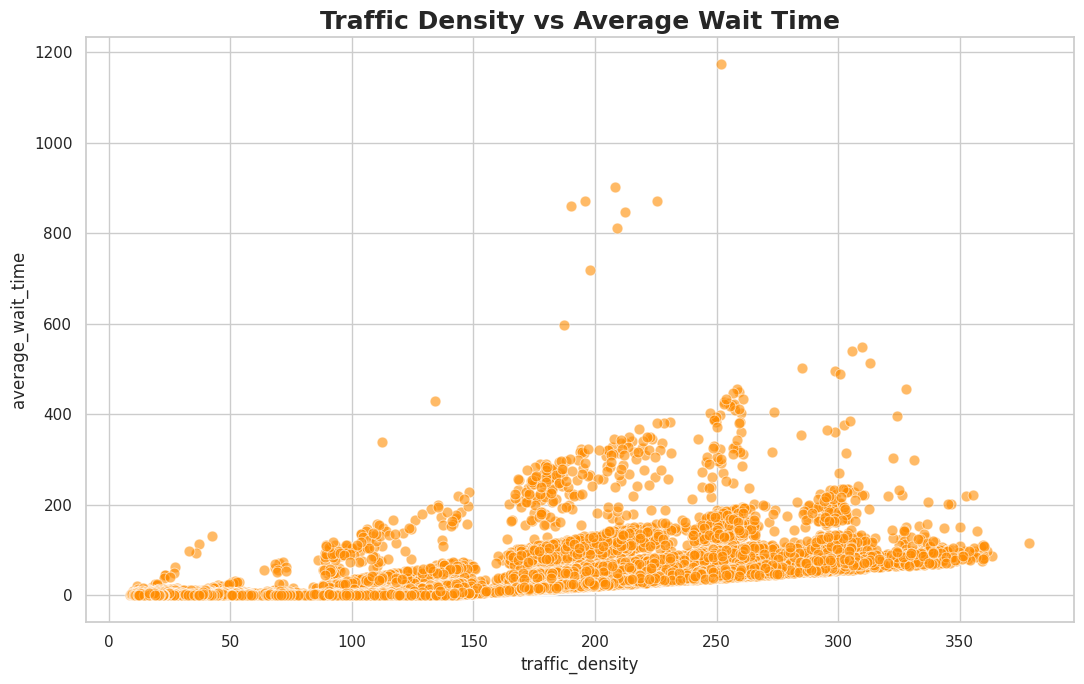

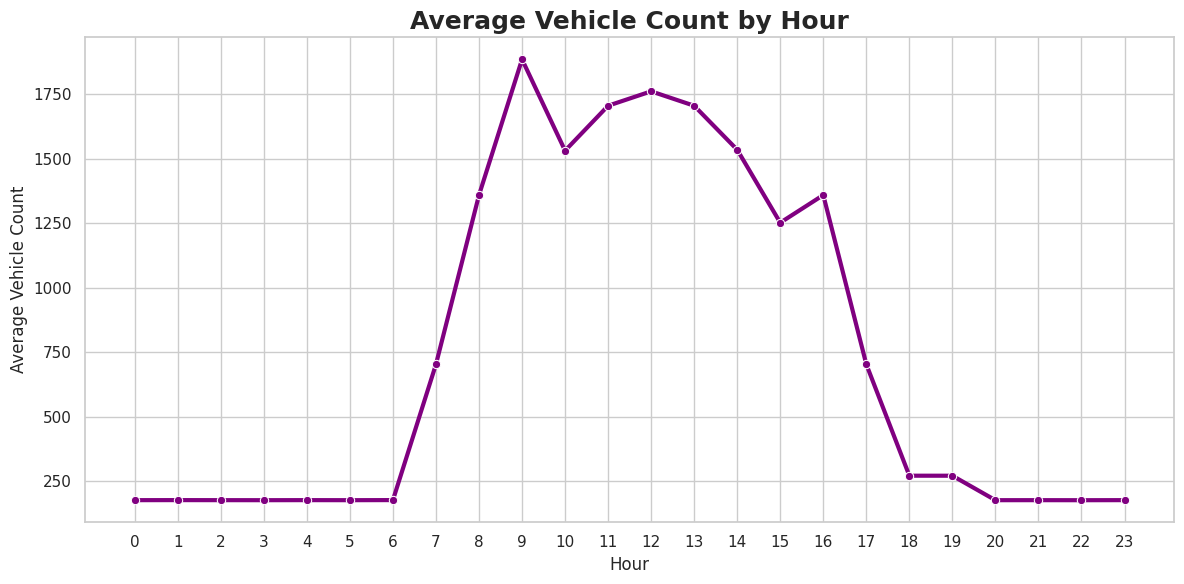

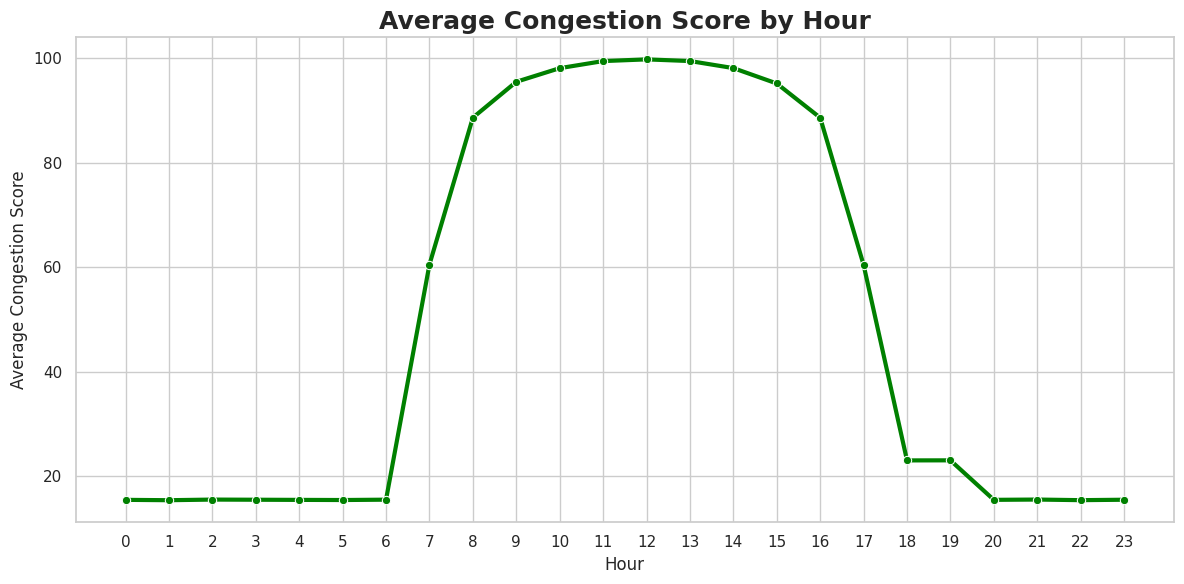

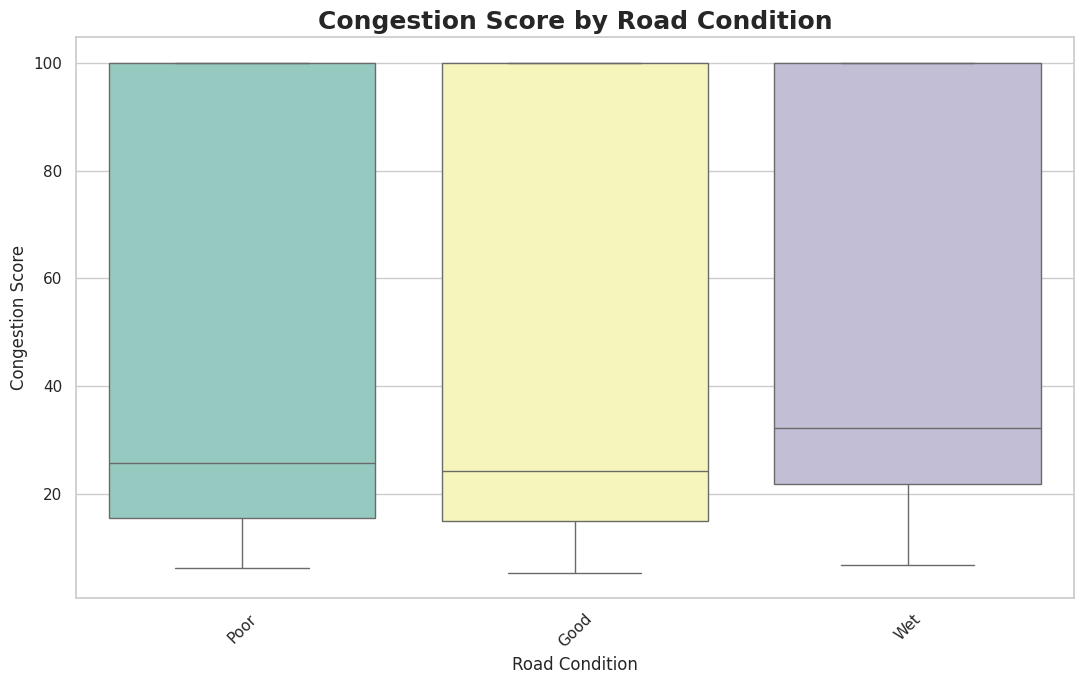

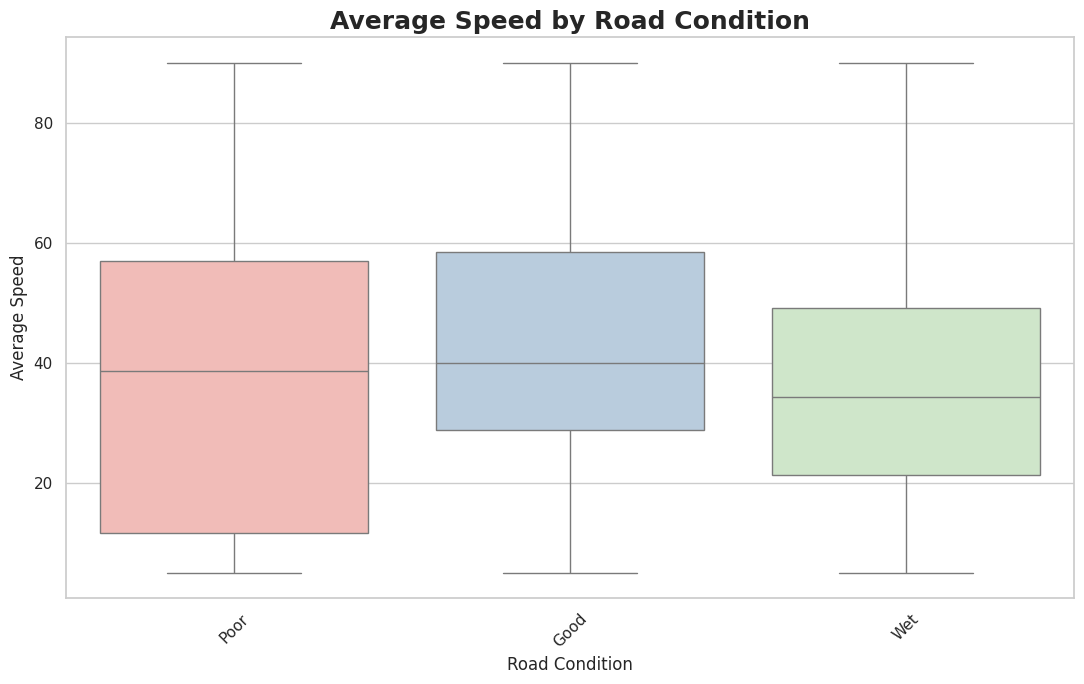

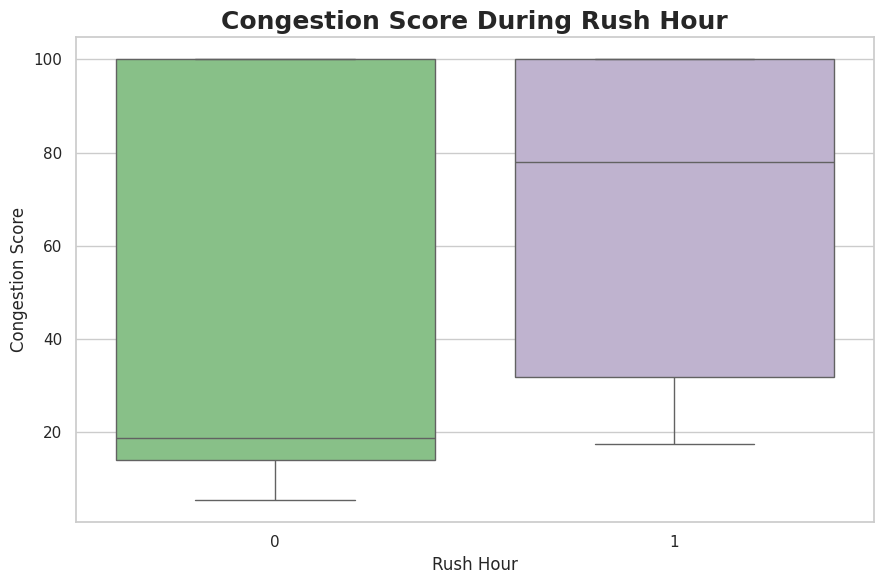

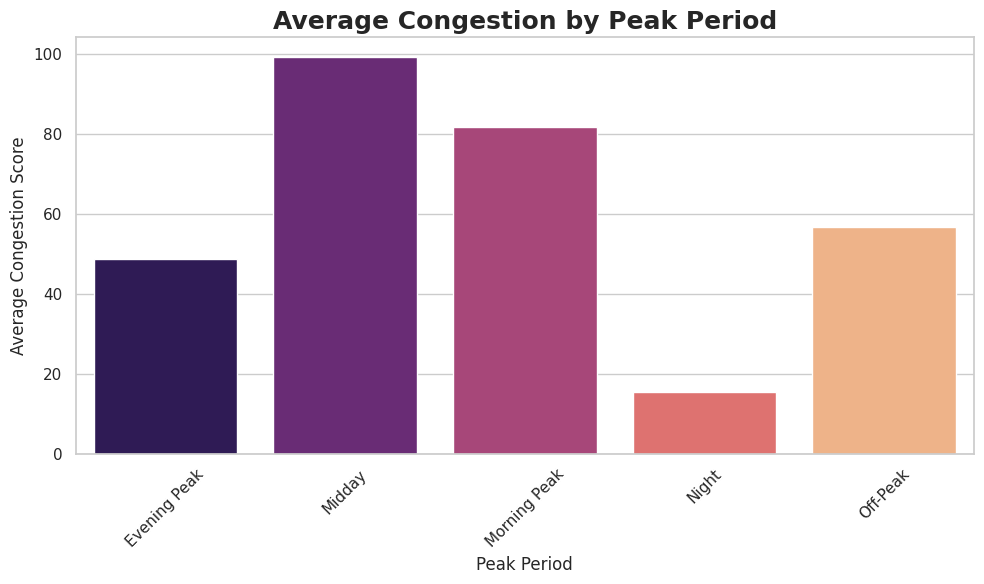

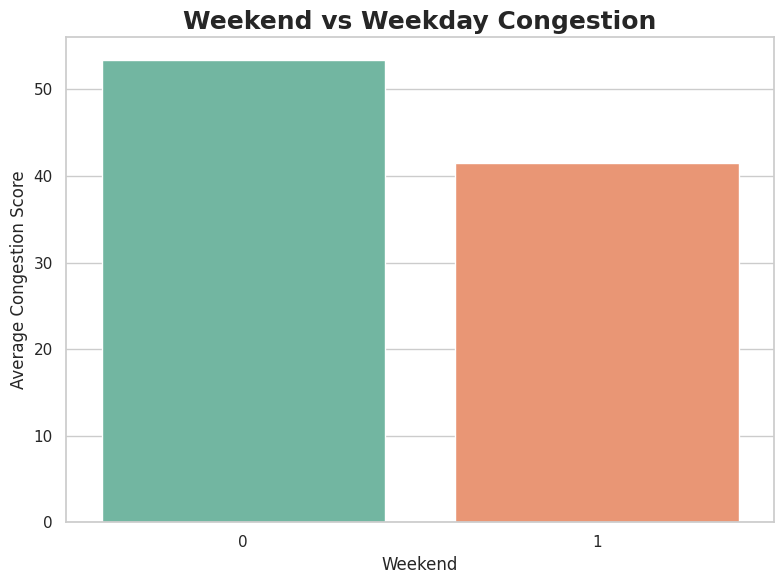

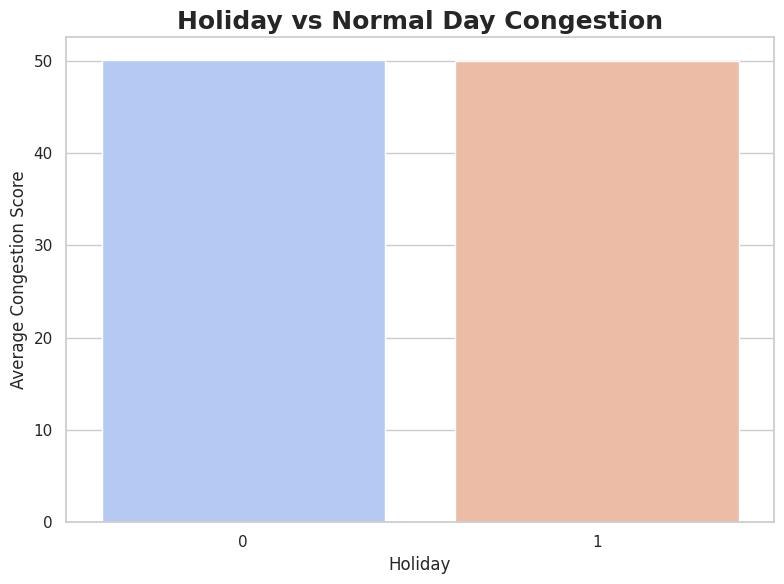

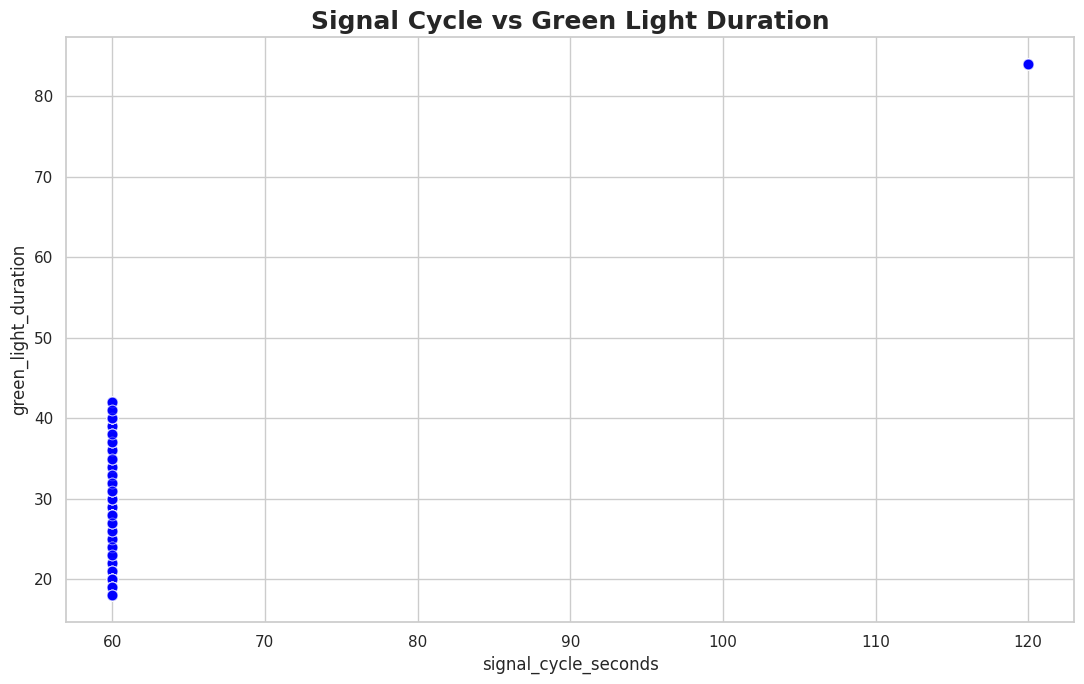

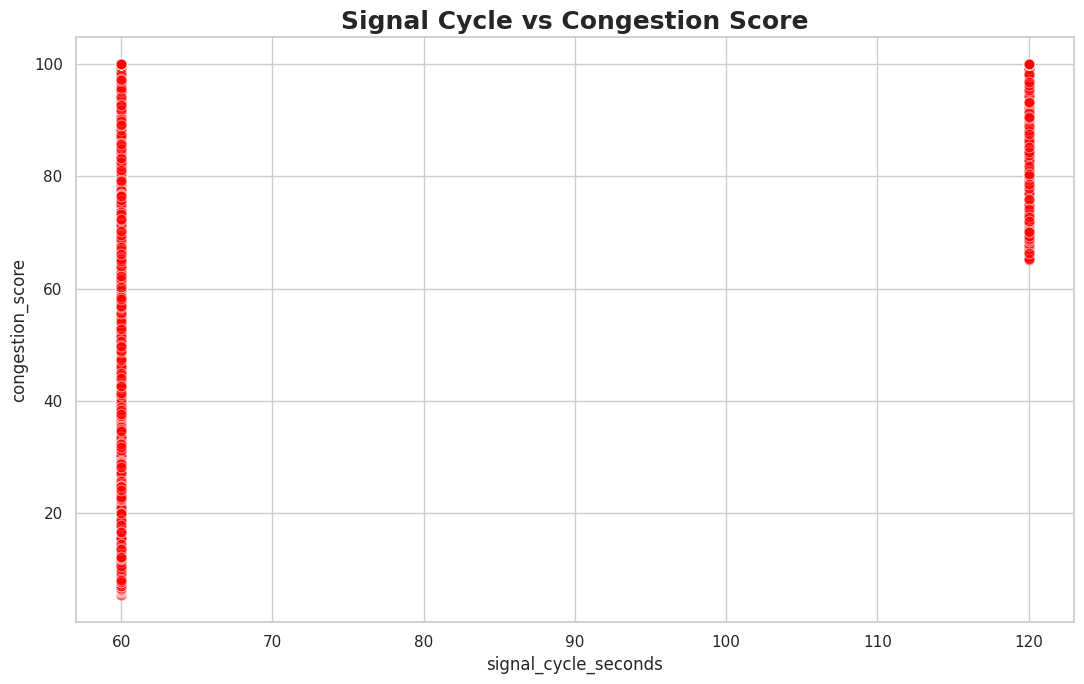

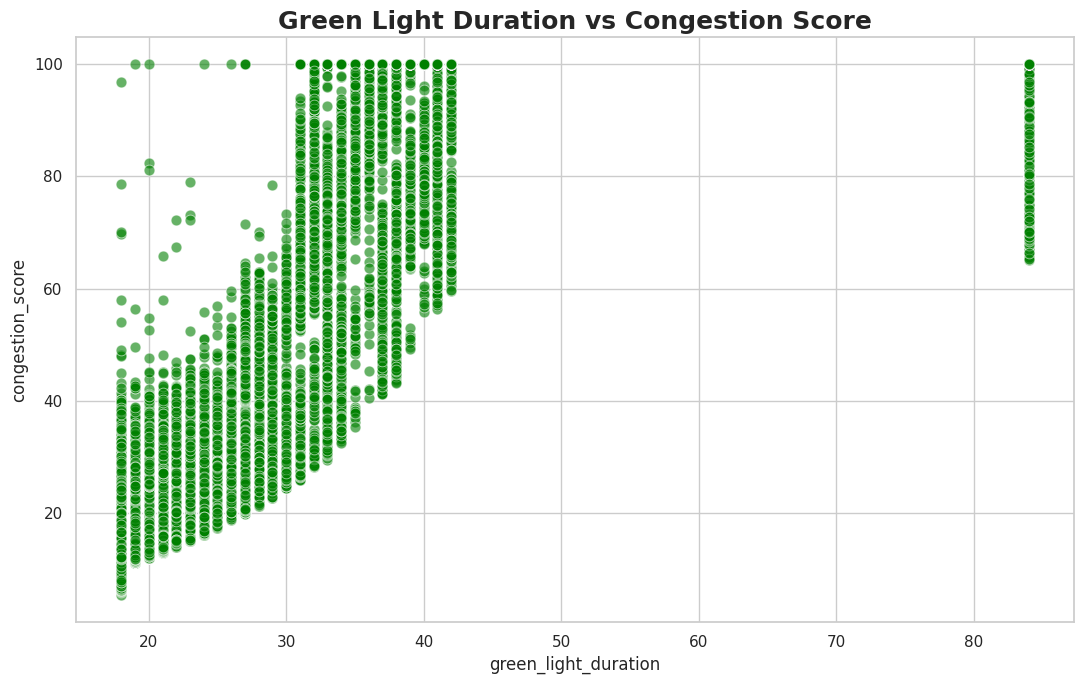

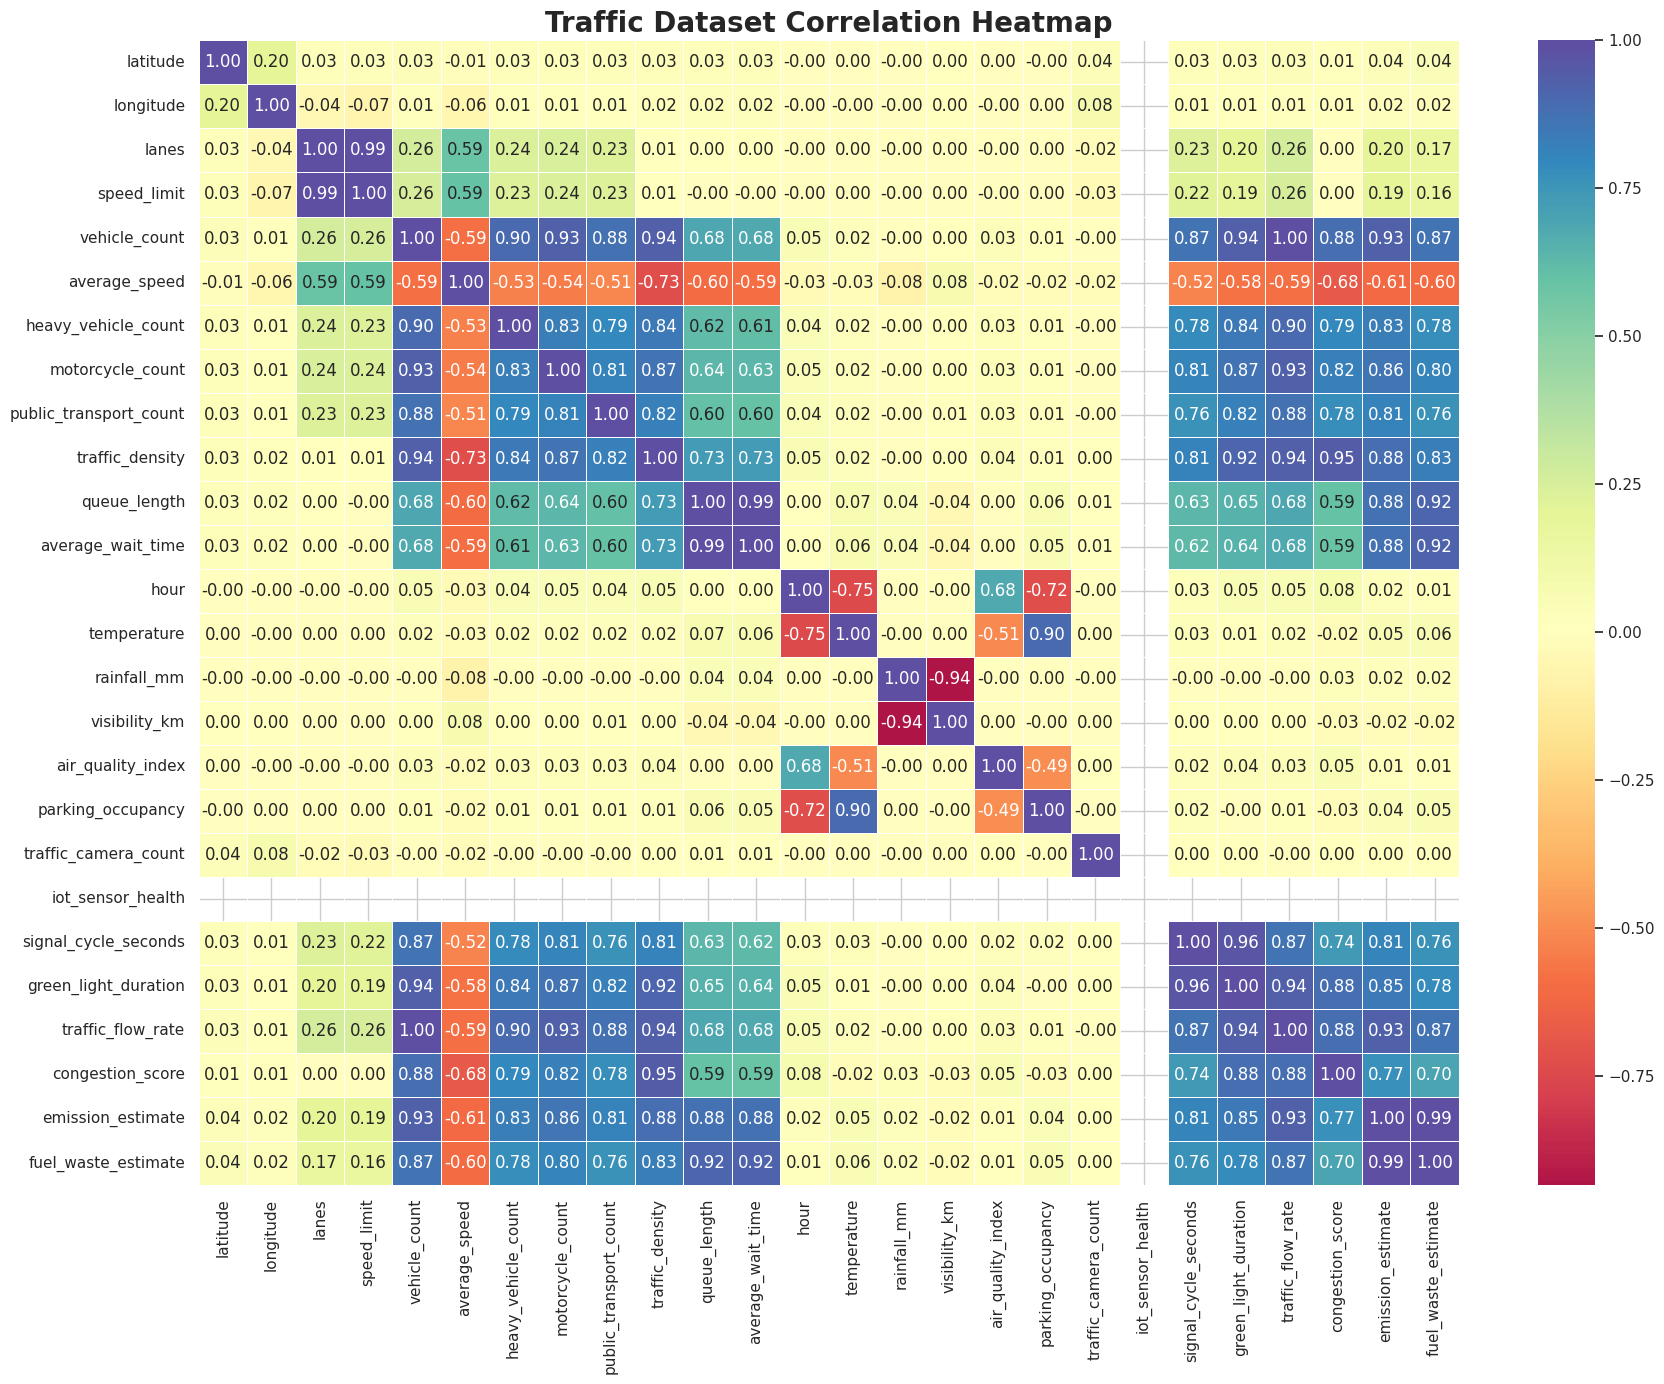


CORRELATION WITH CONGESTION SCORE
congestion_score          1.000000
traffic_density           0.946161
traffic_flow_rate         0.884657
vehicle_count             0.884657
green_light_duration      0.884083
motorcycle_count          0.819153
heavy_vehicle_count       0.794988
public_transport_count    0.775916
emission_estimate         0.765828
signal_cycle_seconds      0.737998
fuel_waste_estimate       0.697130
queue_length              0.594990
average_wait_time         0.589738
hour                      0.079402
air_quality_index         0.053025
rainfall_mm               0.030607
latitude                  0.011764
longitude                 0.007320
traffic_camera_count      0.002056
lanes                     0.001888
speed_limit               0.000449
temperature              -0.021508
visibility_km            -0.027635
parking_occupancy        -0.027908
average_speed            -0.680453
iot_sensor_health              NaN
Name: congestion_score, dtype: float64

NUMERICAL SUMMA

In [12]:
# ============================================================
# TRAFFIC DATASET - COMPLETE EDA & VISUALIZATION
# SAFE VERSION - HANDLES MISSING COLUMNS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. COPY DATA
# ------------------------------------------------------------

data = df.copy()

sns.set_theme(style="whitegrid")

print("=" * 80)
print("TRAFFIC DATASET EDA")
print("=" * 80)

print("Dataset Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

data.columns = data.columns.str.strip()


# ============================================================
# 3. CONVERT TIMESTAMP
# ============================================================

if "timestamp" in data.columns:
    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        errors="coerce"
    )


# ============================================================
# 4. NUMERIC COLUMN CONVERSION
# ============================================================

numeric_columns = [
    "latitude",
    "longitude",
    "lanes",
    "speed_limit",
    "vehicle_count",
    "average_speed",
    "heavy_vehicle_count",
    "motorcycle_count",
    "public_transport_count",
    "traffic_density",
    "queue_length",
    "average_wait_time",
    "hour",
    "temperature",
    "rainfall_mm",
    "visibility_km",
    "air_quality_index",
    "parking_occupancy",
    "traffic_camera_count",
    "iot_sensor_health",
    "signal_cycle_seconds",
    "green_light_duration",
    "traffic_flow_rate",
    "congestion_score",
    "emission_estimate",
    "fuel_waste_estimate"
]

for col in numeric_columns:

    if col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )


# ============================================================
# 5. HANDLE NULL VALUES
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES BEFORE CLEANING")
print("=" * 80)

print(data.isnull().sum())


# Numeric columns -> Median
for col in data.select_dtypes(
    include=np.number
).columns:

    if data[col].isnull().sum() > 0:

        data[col] = data[col].fillna(
            data[col].median()
        )


# Categorical columns -> Mode
for col in data.select_dtypes(
    include=["object", "category"]
).columns:

    if data[col].isnull().sum() > 0:

        mode_value = data[col].mode()

        if len(mode_value) > 0:

            data[col] = data[col].fillna(
                mode_value.iloc[0]
            )

        else:

            data[col] = data[col].fillna(
                "Unknown"
            )


print("\n" + "=" * 80)
print("NULL VALUES AFTER CLEANING")
print("=" * 80)

print(data.isnull().sum())

print(
    "\nTotal remaining null values:",
    data.isnull().sum().sum()
)


# ============================================================
# 6. REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 80)
print("DUPLICATES")
print("=" * 80)

print(
    "Duplicate rows before:",
    data.duplicated().sum()
)

data = data.drop_duplicates()

print(
    "Duplicate rows after:",
    data.duplicated().sum()
)


# ============================================================
# 7. FUNCTION FOR SAFE HISTOGRAM
# ============================================================

def plot_hist(column, color, title):

    if column in data.columns:

        plt.figure(figsize=(10, 6))

        sns.histplot(
            data=data,
            x=column,
            bins=30,
            kde=True,
            color=color
        )

        plt.title(
            title,
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(column)
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()


# ============================================================
# 8. FUNCTION FOR SAFE BAR CHART
# ============================================================

def plot_bar(column, palette, title, top_n=15):

    if column in data.columns:

        counts = (
            data[column]
            .value_counts()
            .head(top_n)
        )

        plt.figure(figsize=(11, 7))

        sns.barplot(
            x=counts.values,
            y=counts.index,
            hue=counts.index,
            palette=palette,
            legend=False
        )

        plt.title(
            title,
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel("Number of Records")
        plt.ylabel(column)

        plt.tight_layout()
        plt.show()


# ============================================================
# 9. FUNCTION FOR SAFE SCATTER PLOT
# ============================================================

def plot_scatter(x, y, title, color):

    if x in data.columns and y in data.columns:

        plt.figure(figsize=(11, 7))

        sns.scatterplot(
            data=data,
            x=x,
            y=y,
            color=color,
            alpha=0.6,
            s=60
        )

        plt.title(
            title,
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(x)
        plt.ylabel(y)

        plt.tight_layout()
        plt.show()


# ============================================================
# 10. NUMERIC DISTRIBUTIONS
# ============================================================

plot_hist(
    "vehicle_count",
    "royalblue",
    "Vehicle Count Distribution"
)

plot_hist(
    "average_speed",
    "darkorange",
    "Average Speed Distribution"
)

plot_hist(
    "traffic_density",
    "teal",
    "Traffic Density Distribution"
)

plot_hist(
    "queue_length",
    "magenta",
    "Queue Length Distribution"
)

plot_hist(
    "congestion_score",
    "crimson",
    "Congestion Score Distribution"
)

plot_hist(
    "air_quality_index",
    "purple",
    "Air Quality Index Distribution"
)

plot_hist(
    "rainfall_mm",
    "dodgerblue",
    "Rainfall Distribution"
)

plot_hist(
    "temperature",
    "tomato",
    "Temperature Distribution"
)


# ============================================================
# 11. ROAD TYPE
# ============================================================

plot_bar(
    "road_type",
    "viridis",
    "Traffic Records by Road Type"
)


# ============================================================
# 12. WEATHER CONDITION
# ============================================================

plot_bar(
    "weather_condition",
    "cool",
    "Traffic Records by Weather Condition"
)


# ============================================================
# 13. ROAD CONDITION
# ============================================================

plot_bar(
    "road_condition",
    "Set1",
    "Traffic Records by Road Condition"
)


# ============================================================
# 14. CITY ZONE
# ============================================================

plot_bar(
    "city_zone",
    "Spectral",
    "Traffic Records by City Zone"
)


# ============================================================
# 15. CONGESTION LEVEL
# ============================================================

plot_bar(
    "congestion_level",
    "magma",
    "Traffic Records by Congestion Level"
)


# ============================================================
# 16. TRAFFIC LEVEL
# ============================================================
# IMPORTANT:
# Your dataset may NOT have traffic_level.
# This check prevents KeyError.

if "traffic_level" in data.columns:

    traffic_counts = (
        data["traffic_level"]
        .value_counts()
    )

    plt.figure(figsize=(9, 6))

    plt.pie(
        traffic_counts.values,
        labels=traffic_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "Set2",
            len(traffic_counts)
        )
    )

    plt.title(
        "Traffic Level Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()

else:

    print(
        "\ntraffic_level column not available - skipped this visualization."
    )


# ============================================================
# 17. ACCIDENT REPORTED
# ============================================================

if "accident_reported" in data.columns:

    accident_counts = (
        data["accident_reported"]
        .value_counts()
    )

    plt.figure(figsize=(8, 6))

    plt.pie(
        accident_counts.values,
        labels=accident_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "Paired",
            len(accident_counts)
        )
    )

    plt.title(
        "Accident Report Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 18. EMERGENCY VEHICLE
# ============================================================

if "emergency_vehicle_detected" in data.columns:

    emergency_counts = (
        data["emergency_vehicle_detected"]
        .value_counts()
    )

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=emergency_counts.index,
        y=emergency_counts.values,
        hue=emergency_counts.index,
        palette="Dark2",
        legend=False
    )

    plt.title(
        "Emergency Vehicle Detection",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(
        "Emergency Vehicle Detected"
    )

    plt.ylabel("Number of Records")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. VEHICLE COMPOSITION
# ============================================================

vehicle_columns = [
    "heavy_vehicle_count",
    "motorcycle_count",
    "public_transport_count"
]

available_vehicle_columns = [
    col for col in vehicle_columns
    if col in data.columns
]

if len(available_vehicle_columns) > 0:

    vehicle_data = (
        data[available_vehicle_columns]
        .mean()
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=vehicle_data.index,
        y=vehicle_data.values,
        hue=vehicle_data.index,
        palette="husl",
        legend=False
    )

    plt.title(
        "Average Vehicle Composition",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Vehicle Category")
    plt.ylabel("Average Count")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. VEHICLE COUNT VS CONGESTION
# ============================================================

plot_scatter(
    "vehicle_count",
    "congestion_score",
    "Vehicle Count vs Congestion Score",
    "royalblue"
)


# ============================================================
# 21. SPEED VS CONGESTION
# ============================================================

plot_scatter(
    "average_speed",
    "congestion_score",
    "Average Speed vs Congestion Score",
    "crimson"
)


# ============================================================
# 22. RAINFALL VS VEHICLE COUNT
# ============================================================

plot_scatter(
    "rainfall_mm",
    "vehicle_count",
    "Rainfall vs Vehicle Count",
    "dodgerblue"
)


# ============================================================
# 23. TEMPERATURE VS CONGESTION
# ============================================================

plot_scatter(
    "temperature",
    "congestion_score",
    "Temperature vs Congestion Score",
    "tomato"
)


# ============================================================
# 24. PARKING VS CONGESTION
# ============================================================

plot_scatter(
    "parking_occupancy",
    "congestion_score",
    "Parking Occupancy vs Congestion Score",
    "green"
)


# ============================================================
# 25. AIR QUALITY VS CONGESTION
# ============================================================

plot_scatter(
    "air_quality_index",
    "congestion_score",
    "Air Quality Index vs Congestion",
    "purple"
)


# ============================================================
# 26. TRAFFIC FLOW VS CONGESTION
# ============================================================

plot_scatter(
    "traffic_flow_rate",
    "congestion_score",
    "Traffic Flow Rate vs Congestion Score",
    "orange"
)


# ============================================================
# 27. EMISSION VS CONGESTION
# ============================================================

plot_scatter(
    "emission_estimate",
    "congestion_score",
    "Emission Estimate vs Congestion Score",
    "brown"
)


# ============================================================
# 28. FUEL WASTE VS CONGESTION
# ============================================================

plot_scatter(
    "fuel_waste_estimate",
    "congestion_score",
    "Fuel Waste vs Congestion Score",
    "teal"
)


# ============================================================
# 29. AVERAGE WAIT TIME VS TRAFFIC DENSITY
# ============================================================

plot_scatter(
    "traffic_density",
    "average_wait_time",
    "Traffic Density vs Average Wait Time",
    "darkorange"
)


# ============================================================
# 30. VEHICLE COUNT BY HOUR
# ============================================================

if "hour" in data.columns and "vehicle_count" in data.columns:

    hourly = (
        data.groupby("hour")["vehicle_count"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=hourly,
        x="hour",
        y="vehicle_count",
        marker="o",
        linewidth=3,
        color="purple"
    )

    plt.title(
        "Average Vehicle Count by Hour",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Hour")
    plt.ylabel("Average Vehicle Count")

    plt.xticks(range(0, 24))

    plt.tight_layout()
    plt.show()


# ============================================================
# 31. CONGESTION BY HOUR
# ============================================================

if "hour" in data.columns and "congestion_score" in data.columns:

    hourly_congestion = (
        data.groupby("hour")["congestion_score"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=hourly_congestion,
        x="hour",
        y="congestion_score",
        marker="o",
        linewidth=3,
        color="green"
    )

    plt.title(
        "Average Congestion Score by Hour",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Hour")
    plt.ylabel("Average Congestion Score")

    plt.xticks(range(0, 24))

    plt.tight_layout()
    plt.show()


# ============================================================
# 32. CONGESTION BY ROAD CONDITION
# ============================================================

if (
    "road_condition" in data.columns
    and "congestion_score" in data.columns
):

    plt.figure(figsize=(11, 7))

    sns.boxplot(
        data=data,
        x="road_condition",
        y="congestion_score",
        hue="road_condition",
        palette="Set3",
        legend=False
    )

    plt.title(
        "Congestion Score by Road Condition",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Road Condition")
    plt.ylabel("Congestion Score")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. SPEED BY ROAD CONDITION
# ============================================================

if (
    "road_condition" in data.columns
    and "average_speed" in data.columns
):

    plt.figure(figsize=(11, 7))

    sns.boxplot(
        data=data,
        x="road_condition",
        y="average_speed",
        hue="road_condition",
        palette="Pastel1",
        legend=False
    )

    plt.title(
        "Average Speed by Road Condition",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Road Condition")
    plt.ylabel("Average Speed")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 34. CONGESTION BY RUSH HOUR
# ============================================================

if (
    "rush_hour" in data.columns
    and "congestion_score" in data.columns
):

    plt.figure(figsize=(9, 6))

    sns.boxplot(
        data=data,
        x="rush_hour",
        y="congestion_score",
        hue="rush_hour",
        palette="Accent",
        legend=False
    )

    plt.title(
        "Congestion Score During Rush Hour",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Rush Hour")
    plt.ylabel("Congestion Score")

    plt.tight_layout()
    plt.show()


# ============================================================
# 35. CONGESTION BY PEAK PERIOD
# ============================================================

if (
    "peak_period" in data.columns
    and "congestion_score" in data.columns
):

    peak_data = (
        data.groupby("peak_period")[
            "congestion_score"
        ]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=peak_data,
        x="peak_period",
        y="congestion_score",
        hue="peak_period",
        palette="magma",
        legend=False
    )

    plt.title(
        "Average Congestion by Peak Period",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Peak Period")
    plt.ylabel("Average Congestion Score")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 36. WEEKEND VS WEEKDAY
# ============================================================

if (
    "is_weekend" in data.columns
    and "congestion_score" in data.columns
):

    weekend_data = (
        data.groupby("is_weekend")[
            "congestion_score"
        ]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 6))

    sns.barplot(
        data=weekend_data,
        x="is_weekend",
        y="congestion_score",
        hue="is_weekend",
        palette="Set2",
        legend=False
    )

    plt.title(
        "Weekend vs Weekday Congestion",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Weekend")
    plt.ylabel("Average Congestion Score")

    plt.tight_layout()
    plt.show()


# ============================================================
# 37. HOLIDAY VS NORMAL DAY
# ============================================================

if (
    "is_holiday" in data.columns
    and "congestion_score" in data.columns
):

    holiday_data = (
        data.groupby("is_holiday")[
            "congestion_score"
        ]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 6))

    sns.barplot(
        data=holiday_data,
        x="is_holiday",
        y="congestion_score",
        hue="is_holiday",
        palette="coolwarm",
        legend=False
    )

    plt.title(
        "Holiday vs Normal Day Congestion",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Holiday")
    plt.ylabel("Average Congestion Score")

    plt.tight_layout()
    plt.show()


# ============================================================
# 38. SIGNAL CYCLE VS GREEN LIGHT
# ============================================================

plot_scatter(
    "signal_cycle_seconds",
    "green_light_duration",
    "Signal Cycle vs Green Light Duration",
    "blue"
)


# ============================================================
# 39. SIGNAL CYCLE VS CONGESTION
# ============================================================

plot_scatter(
    "signal_cycle_seconds",
    "congestion_score",
    "Signal Cycle vs Congestion Score",
    "red"
)


# ============================================================
# 40. GREEN LIGHT VS CONGESTION
# ============================================================

plot_scatter(
    "green_light_duration",
    "congestion_score",
    "Green Light Duration vs Congestion Score",
    "green"
)


# ============================================================
# 41. CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "latitude",
    "longitude",
    "lanes",
    "speed_limit",
    "vehicle_count",
    "average_speed",
    "heavy_vehicle_count",
    "motorcycle_count",
    "public_transport_count",
    "traffic_density",
    "queue_length",
    "average_wait_time",
    "hour",
    "temperature",
    "rainfall_mm",
    "visibility_km",
    "air_quality_index",
    "parking_occupancy",
    "traffic_camera_count",
    "iot_sensor_health",
    "signal_cycle_seconds",
    "green_light_duration",
    "traffic_flow_rate",
    "congestion_score",
    "emission_estimate",
    "fuel_waste_estimate"
]

# Keep ONLY columns that actually exist
available_correlation_columns = [
    col
    for col in correlation_columns
    if col in data.columns
]

if len(available_correlation_columns) >= 2:

    correlation = data[
        available_correlation_columns
    ].corr()

    plt.figure(figsize=(18, 14))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="Spectral",
        center=0,
        linewidths=0.5
    )

    plt.title(
        "Traffic Dataset Correlation Heatmap",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 42. TOP CORRELATIONS WITH CONGESTION
# ============================================================

if "congestion_score" in data.columns:

    correlation_with_target = (
        data[available_correlation_columns]
        .corr()["congestion_score"]
        .sort_values(
            ascending=False
        )
    )

    print("\n" + "=" * 80)
    print("CORRELATION WITH CONGESTION SCORE")
    print("=" * 80)

    print(correlation_with_target)


# ============================================================
# 43. BASIC STATISTICS
# ============================================================

print("\n" + "=" * 80)
print("NUMERICAL SUMMARY")
print("=" * 80)

print(
    data.describe()
)


# ============================================================
# 44. CATEGORICAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("CATEGORICAL SUMMARY")
print("=" * 80)

categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_columns:

    print("\n" + "-" * 50)
    print(col)

    print(
        data[col]
        .value_counts()
        .head(10)
    )


# ============================================================
# 45. FINAL DATASET STATUS
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATASET STATUS")
print("=" * 80)

print(
    "Rows:",
    data.shape[0]
)

print(
    "Columns:",
    data.shape[1]
)

print(
    "Remaining NULL values:",
    data.isnull().sum().sum()
)

print(
    "Remaining duplicate rows:",
    data.duplicated().sum()
)

print("\nEDA + Visualization completed successfully! ✓")

## Features Engineering

TRAFFIC CONGESTION MACHINE LEARNING
Original Shape: (204000, 47)

Duplicate rows: 0
Shape after duplicate removal: (204000, 47)

Target: congestion_level

Target distribution:
congestion_level
Low         101679
Severe       71497
Moderate     15976
High         14848
Name: count, dtype: int64

FEATURE ENGINEERING
Number of features after engineering: 59

Numeric features:
['latitude', 'longitude', 'lanes', 'speed_limit', 'vehicle_count', 'average_speed', 'heavy_vehicle_count', 'motorcycle_count', 'public_transport_count', 'traffic_density', 'queue_length', 'average_wait_time', 'hour', 'day_of_week', 'is_weekend', 'is_holiday', 'rush_hour', 'temperature', 'rainfall_mm', 'visibility_km', 'air_quality_index', 'nearby_school', 'nearby_hospital', 'nearby_market', 'construction_activity', 'parking_occupancy', 'public_event', 'accident_reported', 'traffic_camera_count', 'iot_sensor_health', 'signal_cycle_seconds', 'green_light_duration', 'emergency_vehicle_detected', 'traffic_flow_rate', 'em

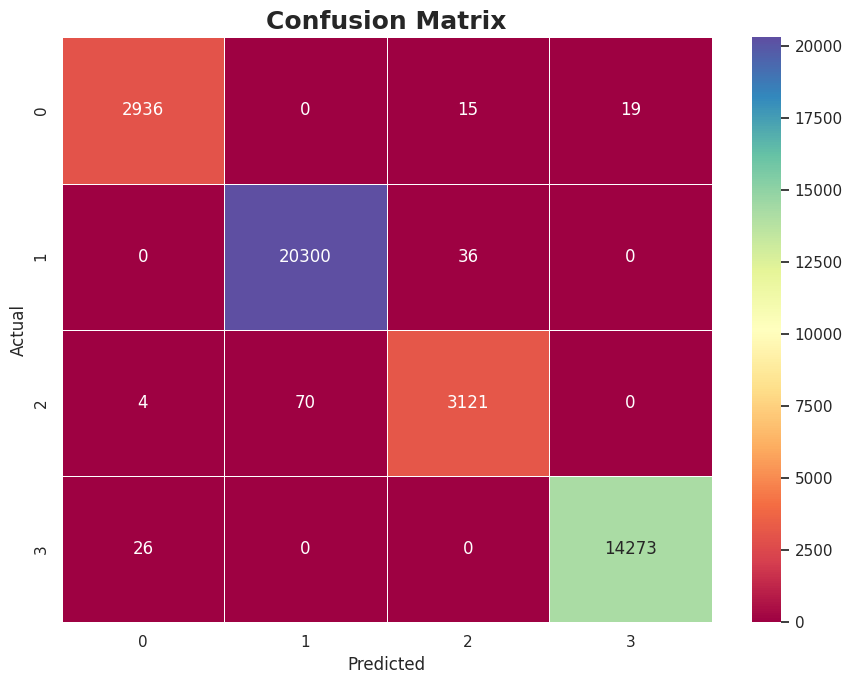


ROC CURVE


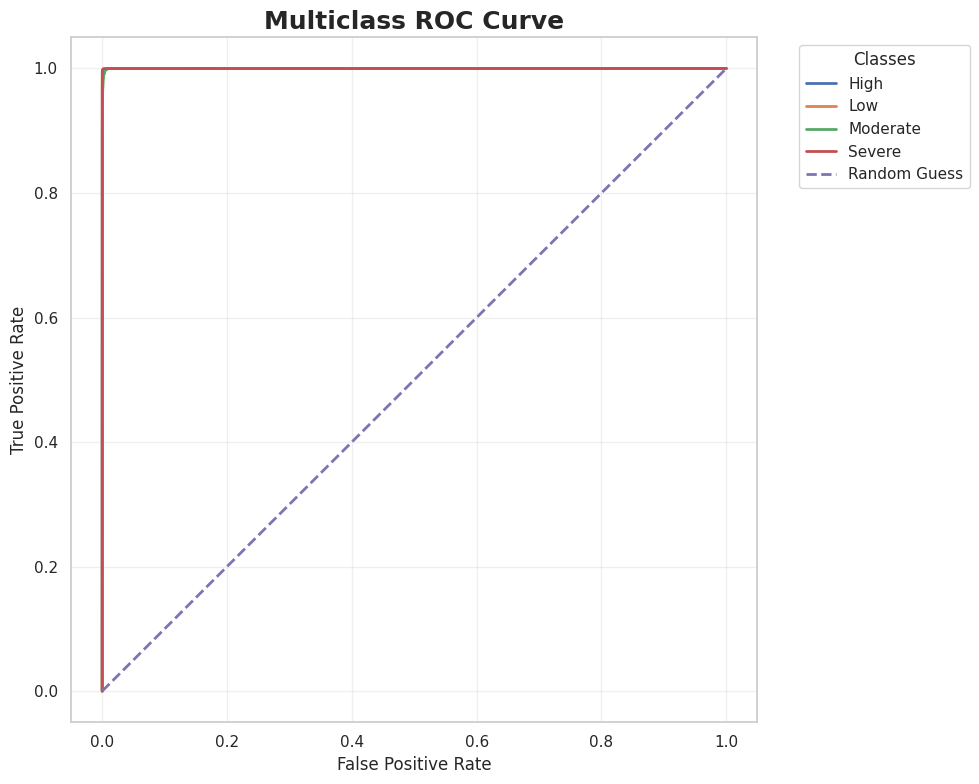

Weighted ROC-AUC Score: 1.0000

FEATURE IMPORTANCE
                                  Feature  Importance
9                numeric__traffic_density    0.155297
36             numeric__vehicles_per_lane    0.142113
38             numeric__speed_utilization    0.068460
34           numeric__fuel_waste_estimate    0.064820
33             numeric__emission_estimate    0.060255
32             numeric__traffic_flow_rate    0.054190
4                  numeric__vehicle_count    0.052464
30          numeric__green_light_duration    0.044965
39             numeric__green_light_ratio    0.041922
5                  numeric__average_speed    0.037994
37              numeric__speed_difference    0.035260
10                  numeric__queue_length    0.033337
11             numeric__average_wait_time    0.022525
57  categorical__peak_period_Evening Peak    0.017187
7               numeric__motorcycle_count    0.016424
41           numeric__queue_vehicle_ratio    0.014851
35   numeric__total_special_veh

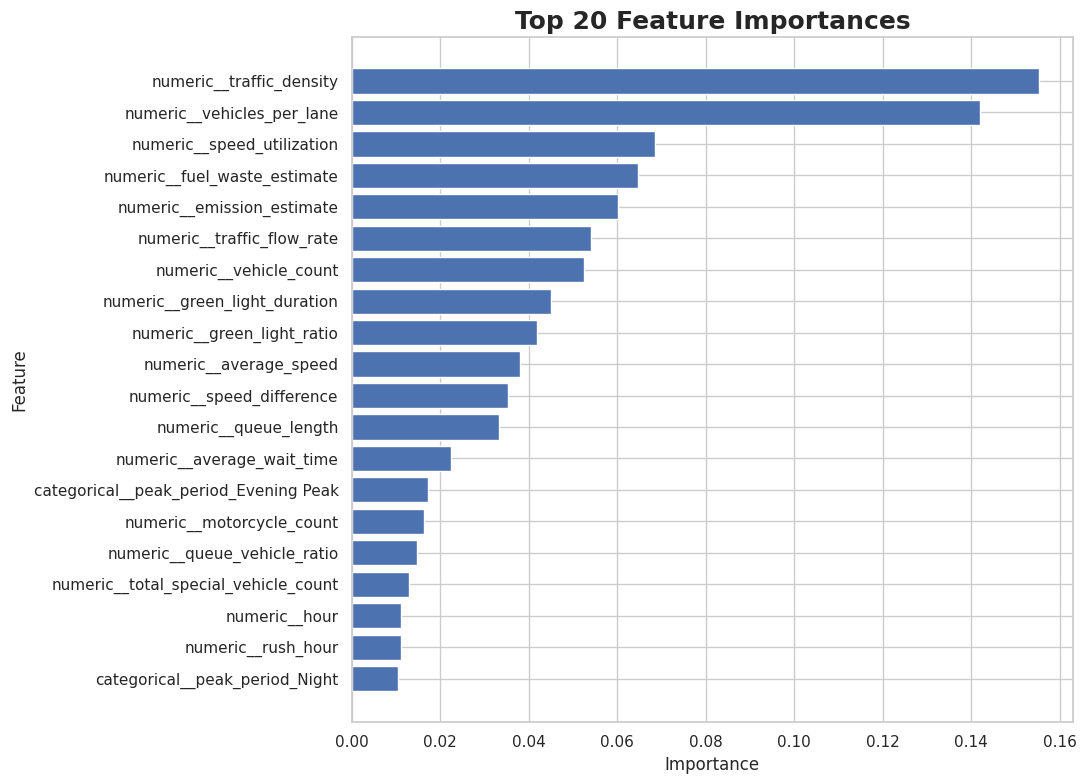


ACTUAL VS PREDICTED
      Actual Predicted
0     Severe    Severe
1        Low       Low
2        Low       Low
3     Severe    Severe
4   Moderate  Moderate
5     Severe    Severe
6     Severe    Severe
7        Low       Low
8        Low       Low
9       High      High
10      High      High
11       Low       Low
12       Low       Low
13       Low       Low
14       Low       Low
15       Low       Low
16    Severe    Severe
17    Severe    Severe
18       Low       Low
19       Low       Low

FINAL MODEL SUMMARY
Model: Random Forest Classifier
Training samples: 163200
Testing samples: 40800
Number of input features: 53
Accuracy: 99.58%
Classification completed successfully!


In [13]:
# ============================================================
# TRAFFIC CONGESTION - MACHINE LEARNING
# FEATURE ENGINEERING + TRAIN TEST + CLASSIFICATION
# ACCURACY + CONFUSION MATRIX + ROC CURVE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()

print("=" * 80)
print("TRAFFIC CONGESTION MACHINE LEARNING")
print("=" * 80)

print("Original Shape:", data.shape)


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

data.columns = data.columns.str.strip()


# ============================================================
# 3. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "latitude",
    "longitude",
    "lanes",
    "speed_limit",
    "vehicle_count",
    "average_speed",
    "heavy_vehicle_count",
    "motorcycle_count",
    "public_transport_count",
    "traffic_density",
    "queue_length",
    "average_wait_time",
    "hour",
    "temperature",
    "rainfall_mm",
    "visibility_km",
    "air_quality_index",
    "parking_occupancy",
    "traffic_camera_count",
    "iot_sensor_health",
    "signal_cycle_seconds",
    "green_light_duration",
    "traffic_flow_rate",
    "congestion_score",
    "emission_estimate",
    "fuel_waste_estimate"
]

for col in numeric_columns:

    if col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

print("\nDuplicate rows:", data.duplicated().sum())

data = data.drop_duplicates()

print(
    "Shape after duplicate removal:",
    data.shape
)


# ============================================================
# 5. TARGET CHECK
# ============================================================

target = "congestion_level"

if target not in data.columns:

    raise ValueError(
        "Target column 'congestion_level' was not found."
    )

print("\nTarget:", target)

print("\nTarget distribution:")

print(
    data[target].value_counts(
        dropna=False
    )
)


# ============================================================
# 6. REMOVE ROWS WITH MISSING TARGET
# ============================================================

data = data.dropna(
    subset=[target]
).reset_index(drop=True)


# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)


# ------------------------------------------------------------
# 7.1 Vehicle composition
# ------------------------------------------------------------

if all(
    col in data.columns
    for col in [
        "heavy_vehicle_count",
        "motorcycle_count",
        "public_transport_count"
    ]
):

    data["total_special_vehicle_count"] = (
        data["heavy_vehicle_count"]
        + data["motorcycle_count"]
        + data["public_transport_count"]
    )


# ------------------------------------------------------------
# 7.2 Vehicle density per lane
# ------------------------------------------------------------

if (
    "vehicle_count" in data.columns
    and "lanes" in data.columns
):

    data["vehicles_per_lane"] = (
        data["vehicle_count"]
        /
        data["lanes"].replace(0, np.nan)
    )


# ------------------------------------------------------------
# 7.3 Speed difference
# ------------------------------------------------------------

if (
    "speed_limit" in data.columns
    and "average_speed" in data.columns
):

    data["speed_difference"] = (
        data["speed_limit"]
        - data["average_speed"]
    )


# ------------------------------------------------------------
# 7.4 Speed utilization
# ------------------------------------------------------------

if (
    "speed_limit" in data.columns
    and "average_speed" in data.columns
):

    data["speed_utilization"] = (
        data["average_speed"]
        /
        data["speed_limit"].replace(
            0,
            np.nan
        )
    )


# ------------------------------------------------------------
# 7.5 Green light ratio
# ------------------------------------------------------------

if (
    "signal_cycle_seconds" in data.columns
    and "green_light_duration" in data.columns
):

    data["green_light_ratio"] = (
        data["green_light_duration"]
        /
        data["signal_cycle_seconds"].replace(
            0,
            np.nan
        )
    )


# ------------------------------------------------------------
# 7.6 Vehicle count per traffic flow
# ------------------------------------------------------------

if (
    "vehicle_count" in data.columns
    and "traffic_flow_rate" in data.columns
):

    data["vehicle_flow_ratio"] = (
        data["vehicle_count"]
        /
        data["traffic_flow_rate"].replace(
            0,
            np.nan
        )
    )


# ------------------------------------------------------------
# 7.7 Queue per vehicle
# ------------------------------------------------------------

if (
    "queue_length" in data.columns
    and "vehicle_count" in data.columns
):

    data["queue_vehicle_ratio"] = (
        data["queue_length"]
        /
        data["vehicle_count"].replace(
            0,
            np.nan
        )
    )


# ------------------------------------------------------------
# 7.8 Weather severity feature
# ------------------------------------------------------------

if "rainfall_mm" in data.columns:

    data["has_rain"] = (
        data["rainfall_mm"] > 0
    ).astype(int)


# ------------------------------------------------------------
# 7.9 Rush hour numeric feature
# ------------------------------------------------------------

if "rush_hour" in data.columns:

    data["rush_hour_numeric"] = (
        data["rush_hour"]
        .astype(str)
        .str.lower()
        .map({
            "yes": 1,
            "true": 1,
            "1": 1,
            "no": 0,
            "false": 0,
            "0": 0
        })
    )


# ------------------------------------------------------------
# 7.10 Weekend numeric feature
# ------------------------------------------------------------

if "is_weekend" in data.columns:

    data["weekend_numeric"] = (
        pd.to_numeric(
            data["is_weekend"],
            errors="coerce"
        )
    )


# ------------------------------------------------------------
# 7.11 Holiday numeric feature
# ------------------------------------------------------------

if "is_holiday" in data.columns:

    data["holiday_numeric"] = (
        pd.to_numeric(
            data["is_holiday"],
            errors="coerce"
        )
    )


# ------------------------------------------------------------
# 7.12 Emergency vehicle feature
# ------------------------------------------------------------

if "emergency_vehicle_detected" in data.columns:

    emergency_numeric = (
        data["emergency_vehicle_detected"]
        .astype(str)
        .str.lower()
        .map({
            "yes": 1,
            "true": 1,
            "1": 1,
            "no": 0,
            "false": 0,
            "0": 0
        })
    )

    data["emergency_vehicle_numeric"] = (
        emergency_numeric
    )


print(
    "Number of features after engineering:",
    data.shape[1]
)


# ============================================================
# 8. REMOVE ID COLUMNS
# ============================================================

id_columns = [
    "record_id",
    "road_id",
    "intersection_id"
]

for col in id_columns:

    if col in data.columns:

        data = data.drop(
            columns=col
        )


# ============================================================
# 9. REMOVE TIMESTAMP
# ============================================================

# We already have hour/day/weekend/holiday
# so the raw timestamp is not necessary.

if "timestamp" in data.columns:

    data = data.drop(
        columns=["timestamp"]
    )


# ============================================================
# 10. PREPARE X AND y
# ============================================================

X = data.drop(
    columns=[target]
)

y = data[target].copy()


# ============================================================
# 11. REMOVE POTENTIAL TARGET LEAKAGE
# ============================================================

# IMPORTANT:
#
# If congestion_level was directly created from
# congestion_score, using congestion_score as a feature
# can create leakage.
#
# Therefore remove congestion_score when predicting
# congestion_level.

leakage_columns = [
    "congestion_score"
]

for col in leakage_columns:

    if col in X.columns:

        X = X.drop(
            columns=[col]
        )


# ============================================================
# 12. REMOVE HIGH-CARDINALITY IDENTIFIERS
# ============================================================

# Columns such as city/road names may contain thousands
# of unique values. We keep useful categorical columns,
# but remove extremely high-cardinality identifiers.

high_cardinality_columns = []

for col in X.select_dtypes(
    include=["object", "category"]
).columns:

    unique_ratio = (
        X[col].nunique(dropna=True)
        /
        len(X)
    )

    if unique_ratio > 0.50:

        high_cardinality_columns.append(
            col
        )


if len(high_cardinality_columns) > 0:

    print(
        "\nRemoving high-cardinality columns:"
    )

    print(
        high_cardinality_columns
    )

    X = X.drop(
        columns=high_cardinality_columns
    )


# ============================================================
# 13. IDENTIFY NUMERIC / CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ============================================================
# 14. TRAIN TEST SPLIT
# ============================================================

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)


# ------------------------------------------------------------
# Check whether stratification is possible
# ------------------------------------------------------------

class_counts = y.value_counts()

if (
    len(class_counts) > 1
    and class_counts.min() >= 2
):

    stratify_value = y

else:

    stratify_value = None

    print(
        "Stratification disabled because "
        "one or more classes have fewer than 2 samples."
    )


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_value
)


print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)


# ============================================================
# 15. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ============================================================
# 16. RANDOM FOREST CLASSIFIER
# ============================================================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


# ============================================================
# 17. COMPLETE PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            model
        )
    ]
)


# ============================================================
# 18. TRAIN MODEL
# ============================================================

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

pipeline.fit(
    X_train,
    y_train
)

print(
    "Model training completed successfully!"
)


# ============================================================
# 19. PREDICTION
# ============================================================

y_pred = pipeline.predict(
    X_test
)


# ============================================================
# 20. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 80)
print("MODEL ACCURACY")
print("=" * 80)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Spectral",
    linewidths=0.5
)

plt.title(
    "Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 23. ROC CURVE
# ============================================================

print("\n" + "=" * 80)
print("ROC CURVE")
print("=" * 80)


# ROC works differently for binary and multiclass
# classification.

classes = pipeline.classes_

if len(classes) == 2:

    # --------------------------------------------------------
    # Binary classification
    # --------------------------------------------------------

    y_probability = pipeline.predict_proba(
        X_test
    )[:, 1]

    # Convert labels to 0/1 for ROC
    y_binary = (
        y_test == classes[1]
    ).astype(int)

    fpr, tpr, thresholds = roc_curve(
        y_binary,
        y_probability
    )

    auc_score = roc_auc_score(
        y_binary,
        y_probability
    )

    plt.figure(figsize=(9, 7))

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=f"Random Forest (AUC = {auc_score:.3f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "ROC Curve",
        fontsize=18,
        fontweight="bold"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(
        f"ROC-AUC Score: {auc_score:.4f}"
    )


elif len(classes) > 2:

    # --------------------------------------------------------
    # Multiclass classification
    # --------------------------------------------------------

    from sklearn.preprocessing import label_binarize

    y_test_encoded = label_binarize(
        y_test,
        classes=classes
    )

    y_probability = pipeline.predict_proba(
        X_test
    )

    auc_score = roc_auc_score(
        y_test_encoded,
        y_probability,
        multi_class="ovr",
        average="weighted"
    )

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_encoded[:, i],
            y_probability[:, i]
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=str(class_name)
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Guess"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "Multiclass ROC Curve",
        fontsize=18,
        fontweight="bold"
    )

    plt.legend(
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(
        f"Weighted ROC-AUC Score: {auc_score:.4f}"
    )


else:

    print(
        "ROC curve cannot be calculated because "
        "the target contains only one class."
    )


# ============================================================
# 24. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)


rf_model = pipeline.named_steps[
    "classifier"
]

preprocessor_fitted = pipeline.named_steps[
    "preprocessor"
]


# Get transformed feature names
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)


importance = rf_model.feature_importances_


feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})


feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print(
    feature_importance.head(20)
)


# ============================================================
# 25. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = (
    feature_importance
    .head(20)
    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 20 Feature Importances",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# 26. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

print("\n" + "=" * 80)
print("ACTUAL VS PREDICTED")
print("=" * 80)

print(
    comparison.head(20)
)


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL SUMMARY")
print("=" * 80)

print(
    "Model: Random Forest Classifier"
)

print(
    f"Training samples: {len(X_train)}"
)

print(
    f"Testing samples: {len(X_test)}"
)

print(
    f"Number of input features: {X.shape[1]}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print(
    "Classification completed successfully!"
)

## Thanks..........Please Upvote